# Cómputo y Programación Cuántica

---

| Bloque | Tema | Temas |
|--------|------|-------|
| **1** | Fundamentos | Qubits, Álgebra lineal, Mecánica cuántica |
| **2** | Introducción a QC | Circuitos, Compuertas, Qiskit |
| **3** | Algoritmos fundamentales | Deutsch, DJ, BV, Simon, Grover, SWAP test |
| **4** | Programación avanzada | PennyLane, programación híbrida |
| **5** | Algoritmos avanzados | QAOA, QFT, QPE, HHL, QML |

> **Instalación recomendada:**
> ```bash
> pip install numpy matplotlib scipy qiskit qiskit-aer qiskit-ibm-runtime pennylane pennylane-qiskit
> ```


---
# BLOQUE 1 — Fundamentos


## Tema 1: ¿Qué es una Computadora Cuántica?

### 1.1 Diferencias con la computación clásica

| Característica | Clásica | Cuántica |
|---|---|---|
| Unidad básica | Bit ($b \in \{0,1\}$) | Qubit ($\|\psi\rangle = \alpha\|0\rangle + \beta\|1\rangle$) |
| Paralelismo | Secuencial | Superposición de $2^n$ estados simultáneos |
| Reversibilidad | Irreversible (NAND, OR) | Toda evolución es unitaria → reversible |
| Corrección de errores | Trivial (copia de bit) | Imposible copiar estado cuántico (No-Cloning) |
| Modelo de cómputo | Circuito booleano | Circuito cuántico unitario |
| Ventaja | Práctico, robusto | Exponencial en ciertos problemas |

### 1.2 Qubit vs Bit clásico

Un **bit** clásico es determinista: $b = 0$ ó $b = 1$.

Un **qubit** vive en un espacio de Hilbert de dimensión 2:
$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle, \qquad \alpha,\beta \in \mathbb{C}, \quad |\alpha|^2+|\beta|^2=1$$

- $|\alpha|^2$ = probabilidad de medir $|0\rangle$
- $|\beta|^2$ = probabilidad de medir $|1\rangle$
- La **esfera de Bloch** parametriza todos los estados puros: $|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle$

### 1.3 Aplicaciones potenciales

| Área | Aplicación | Algoritmo | Speedup |
|------|-----------|-----------|---------|
| Criptografía | Factorización RSA | Shor | Exponencial |
| Búsqueda | Bases de datos no estructuradas | Grover | Cuadrático |
| Química | Simulación molecular | VQE | Exponencial |
| Optimización | Logística, finanzas | QAOA | Polinomial |
| ML | Clasificación, regresión | VQC, QSVM | Potencial exponencial |
| Álgebra lineal | Sistemas de ecuaciones | HHL | Exponencial |


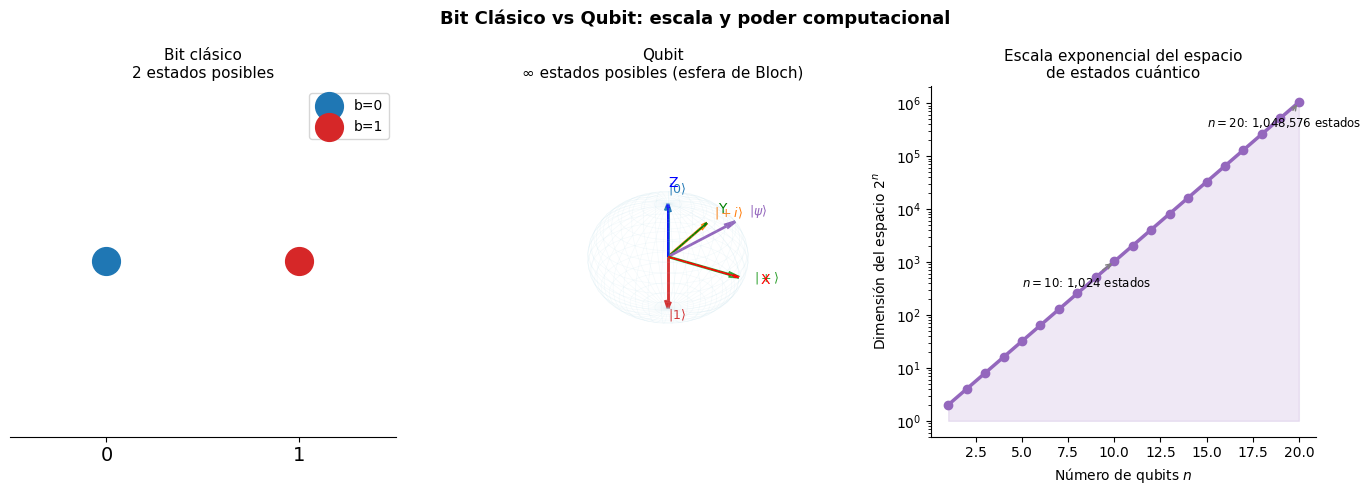

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ── Visualización: Bit clásico vs Qubit ──────────────────────────────────────
fig = plt.figure(figsize=(14, 5))

# Izquierda: bit clásico — solo dos estados posibles
ax1 = fig.add_subplot(131)
ax1.scatter([0], [0], s=400, color='#1F77B4', zorder=5, label='b=0')
ax1.scatter([1], [0], s=400, color='#D62728', zorder=5, label='b=1')
ax1.set_xlim(-0.5, 1.5); ax1.set_ylim(-0.5, 0.5)
ax1.set_title('Bit clásico\n2 estados posibles', fontsize=11)
ax1.set_xticks([0,1]); ax1.set_xticklabels(['0','1'], fontsize=14)
ax1.set_yticks([]); ax1.legend(fontsize=10)
ax1.spines[['top','right','left']].set_visible(False)

# Centro: qubit — continuo de estados en la esfera de Bloch
ax2 = fig.add_subplot(132, projection='3d')
u = np.linspace(0, 2*np.pi, 40); v = np.linspace(0, np.pi, 20)
ax2.plot_wireframe(np.outer(np.cos(u),np.sin(v)),
                   np.outer(np.sin(u),np.sin(v)),
                   np.outer(np.ones_like(u),np.cos(v)),
                   color='lightblue', alpha=0.15, linewidth=0.4)
# Algunos estados de ejemplo
states_bv = [(0,0,'#1F77B4',r'$|0\rangle$'),
             (np.pi,0,'#D62728',r'$|1\rangle$'),
             (np.pi/2,0,'#2CA02C',r'$|+\rangle$'),
             (np.pi/2,np.pi/2,'#FF7F0E',r'$|+i\rangle$'),
             (np.pi/3,np.pi/4,'#9467BD',r'$|\psi\rangle$')]
for th,ph,col,lbl in states_bv:
    bv = [np.sin(th)*np.cos(ph), np.sin(th)*np.sin(ph), np.cos(th)]
    ax2.quiver(0,0,0,*bv, color=col, linewidth=2, arrow_length_ratio=0.15)
    ax2.text(bv[0]*1.2, bv[1]*1.2, bv[2]*1.2, lbl, color=col, fontsize=9)
for d,lbl,c in [([1,0,0],'X','r'),([0,1,0],'Y','g'),([0,0,1],'Z','b')]:
    ax2.quiver(0,0,0,*d,color=c,linewidth=1.2,arrow_length_ratio=0.08)
    ax2.text(d[0]*1.3,d[1]*1.3,d[2]*1.3,lbl,color=c,fontsize=10)
ax2.set_xlim(-1.4,1.4); ax2.set_ylim(-1.4,1.4); ax2.set_zlim(-1.4,1.4)
ax2.set_axis_off()
ax2.set_title('Qubit\n∞ estados posibles (esfera de Bloch)', fontsize=11)

# Derecha: potencia computacional (2^n)
ax3 = fig.add_subplot(133)
ns = np.arange(1, 21)
ax3.semilogy(ns, 2**ns, 'o-', color='#9467BD', linewidth=2.5, markersize=6)
ax3.fill_between(ns, 1, 2**ns, alpha=0.15, color='#9467BD')
ax3.set_xlabel('Número de qubits $n$')
ax3.set_ylabel('Dimensión del espacio $2^n$')
ax3.set_title('Escala exponencial del espacio\nde estados cuántico', fontsize=11)
ax3.spines[['top','right']].set_visible(False)
for n_mark in [10, 20]:
    ax3.annotate(f'$n={n_mark}$: {2**n_mark:,} estados',
                 xy=(n_mark, 2**n_mark), xytext=(n_mark-5, 2**n_mark/3),
                 arrowprops=dict(arrowstyle='->', color='gray'),
                 fontsize=8.5)

plt.suptitle('Bit Clásico vs Qubit: escala y poder computacional', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Tema 2: Álgebra Lineal para Cómputo Cuántico

### 2.1 Vectores, Matrices y Productos Internos

El estado de un sistema cuántico de $n$ qubits vive en $\mathbb{C}^{2^n}$.

**Notación de Dirac:**

$$|0\rangle = \begin{pmatrix}1\\0\end{pmatrix}, \quad
|1\rangle = \begin{pmatrix}0\\1\end{pmatrix}, \quad
\langle\psi| = |\psi\rangle^\dagger = \bar{\alpha}\begin{pmatrix}1&0\end{pmatrix} + \bar{\beta}\begin{pmatrix}0&1\end{pmatrix}$$

**Producto interno** (braket):
$$\langle\phi|\psi\rangle = \sum_i \bar{\phi}_i \psi_i \in \mathbb{C}$$

Propiedades: $\langle\phi|\psi\rangle = \overline{\langle\psi|\phi\rangle}$, $\langle\psi|\psi\rangle \geq 0$, lineal en el segundo argumento.

**Norma:** $\||\psi\rangle\| = \sqrt{\langle\psi|\psi\rangle}$

**Ortonormalidad** de la base computacional: $\langle i|j\rangle = \delta_{ij}$

**Completitud:** $\sum_i |i\rangle\langle i| = I$ (resolución de la identidad)

### 2.2 Operadores Unitarios y Hermíticos

| Tipo | Definición | Propiedad | Rol cuántico |
|------|-----------|-----------|-------------|
| **Hermítico** | $A^\dagger = A$ | Valores propios reales | Observables |
| **Unitario** | $U^\dagger U = I$ | Preserva norma | Puertas cuánticas |
| **Proyector** | $P^2 = P = P^\dagger$ | Valores propios 0,1 | Medición |
| **Normal** | $[A,A^\dagger]=0$ | Diagonalizable | General |

**Descomposición espectral** (operador Hermítico):
$$A = \sum_i \lambda_i |e_i\rangle\langle e_i|, \qquad \lambda_i \in \mathbb{R}$$

**Matrices de Pauli** (base del espacio de operadores en 1 qubit):
$$\sigma_0 = I = \begin{pmatrix}1&0\\0&1\end{pmatrix}, \quad
\sigma_1 = X = \begin{pmatrix}0&1\\1&0\end{pmatrix}, \quad
\sigma_2 = Y = \begin{pmatrix}0&-i\\i&0\end{pmatrix}, \quad
\sigma_3 = Z = \begin{pmatrix}1&0\\0&-1\end{pmatrix}$$

### 2.3 Producto Tensorial y Matrices Densas

**Producto tensorial** $A \otimes B$ combina sistemas:
$$A \otimes B = \begin{pmatrix}a_{11}B & a_{12}B \\ a_{21}B & a_{22}B\end{pmatrix}$$

Estado de $n$ qubits: $|\psi_1\rangle \otimes |\psi_2\rangle \otimes \cdots \otimes |\psi_n\rangle \in \mathbb{C}^{2^n}$

**Matriz densa** (operador de densidad): $\rho = |\psi\rangle\langle\psi|$ — describe estados mixtos y sistemas abiertos.


In [ ]:
import numpy as np

# ── Álgebra lineal cuántica: implementación completa ─────────────────────────

# Bases y operadores fundamentales
KET0 = np.array([1, 0], dtype=complex)
KET1 = np.array([0, 1], dtype=complex)

I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]], dtype=complex)
Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
Z  = np.array([[1,0],[0,-1]], dtype=complex)
H  = np.array([[1,1],[1,-1]], dtype=complex) / np.sqrt(2)
S  = np.array([[1,0],[0,1j]], dtype=complex)
T  = np.array([[1,0],[0,np.exp(1j*np.pi/4)]], dtype=complex)

def ket(v): return np.array(v, dtype=complex)
def bra(psi): return psi.conj()
def braket(phi, psi): return np.dot(bra(phi), psi)
def outer(phi, psi): return np.outer(phi, bra(psi))
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0], tensor(*ops[1:]))
def dagger(A): return A.conj().T
def commutator(A, B): return A@B - B@A
def expectation(psi, O): return np.real(np.dot(bra(psi), O @ psi))
def density(psi): return outer(psi, psi)
def is_unitary(U, tol=1e-10): return np.max(np.abs(U@dagger(U) - np.eye(len(U)))) < tol
def is_hermitian(A, tol=1e-10): return np.max(np.abs(A - dagger(A))) < tol

# ── Verificar propiedades ────────────────────────────────────────────────────
print("=== Verificación de propiedades algebraicas ===")
print(f"X unitario: {is_unitary(X)}")
print(f"Y unitario: {is_unitary(Y)}")
print(f"Z unitario: {is_unitary(Z)}")
print(f"H unitario: {is_unitary(H)}")
print(f"X hermítico: {is_hermitian(X)}")
print(f"Y hermítico: {is_hermitian(Y)}")
print(f"Z hermítico: {is_hermitian(Z)}")
print()
print("Anticonmutación {X,Y} = XY+YX:")
anticomm = X@Y + Y@X
print(f"  XY + YX = {anticomm}  (debe ser 0)")
print(f"  XY = {X@Y.round(4)} = iZ? {np.allclose(X@Y, 1j*Z)}")

# ── Producto tensorial ────────────────────────────────────────────────────────
print("\n=== Producto tensorial ===")
psi_A = H @ KET0  # |+⟩
psi_B = KET0      # |0⟩
psi_AB = tensor(psi_A, psi_B)
print(f"|+⟩ ⊗ |0⟩ = {psi_AB.round(4)}")
print(f"Norma: {np.linalg.norm(psi_AB):.6f}")

HH = tensor(H, H)
print(f"\nH⊗H (4x4) aplicado a |00⟩:")
state_00 = tensor(KET0, KET0)
result = HH @ state_00
print(f"  {result.round(4)}")
print(f"  (distribución uniforme: todos los estados con prob 1/4)")

# ── Descomposición espectral ─────────────────────────────────────────────────
print("\n=== Descomposición espectral de Z ===")
eigenvalues, eigenvectors = np.linalg.eigh(Z)
print(f"Valores propios: {eigenvalues}")
print(f"Vectores propios:")
for lam, ev in zip(eigenvalues, eigenvectors.T):
    print(f"  λ={lam:.0f}: {ev}")
# Reconstruir
Z_rec = sum(lam * outer(ev, ev) for lam, ev in zip(eigenvalues, eigenvectors.T))
print(f"Reconstrucción Z = Σ λᵢ|eᵢ⟩⟨eᵢ|: {np.allclose(Z_rec, Z)}")

# ── Operador de densidad ─────────────────────────────────────────────────────
print("\n=== Operador de densidad ===")
psi_plus = ket([1,1])/np.sqrt(2)
rho = density(psi_plus)
print(f"ρ = |+⟩⟨+| =\n{rho}")
print(f"Tr(ρ) = {np.real(np.trace(rho)):.4f}  (debe ser 1)")
print(f"Tr(ρ²) = {np.real(np.trace(rho@rho)):.4f}  (1=puro, <1=mezclado)")
# Estado mezclado (50/50 sin coherencia)
rho_mixed = 0.5 * density(KET0) + 0.5 * density(KET1)
print(f"\nEstado mezclado (mezcla 50/50 |0⟩,|1⟩):")
print(f"  Tr(ρ²) = {np.real(np.trace(rho_mixed@rho_mixed)):.4f}  (=0.5, estado mezclado)")


=== Verificación de propiedades algebraicas ===
X unitario: True
Y unitario: True
Z unitario: True
H unitario: True
X hermítico: True
Y hermítico: True
Z hermítico: True

Anticonmutación {X,Y} = XY+YX:
  XY + YX = [[0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]  (debe ser 0)
  XY = [[0.+1.j 0.+0.j]
 [0.+0.j 0.-1.j]] = iZ? True

=== Producto tensorial ===
|+⟩ ⊗ |0⟩ = [0.7071+0.j 0.    +0.j 0.7071+0.j 0.    +0.j]
Norma: 1.000000

H⊗H (4x4) aplicado a |00⟩:
  [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
  (distribución uniforme: todos los estados con prob 1/4)

=== Descomposición espectral de Z ===
Valores propios: [-1.  1.]
Vectores propios:
  λ=-1: [0.+0.j 1.+0.j]
  λ=1: [1.+0.j 0.+0.j]
Reconstrucción Z = Σ λᵢ|eᵢ⟩⟨eᵢ|: True

=== Operador de densidad ===
ρ = |+⟩⟨+| =
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]
Tr(ρ) = 1.0000  (debe ser 1)
Tr(ρ²) = 1.0000  (1=puro, <1=mezclado)

Estado mezclado (mezcla 50/50 |0⟩,|1⟩):
  Tr(ρ²) = 0.5000  (=0.5, estado mezclado)


---
## Tema 3: Introducción a la Mecánica Cuántica

### 3.1 Postulados Fundamentales

La mecánica cuántica descansa sobre 4 postulados:

**Postulado 1 — Estado:** Todo sistema físico aislado se describe por un vector de estado $|\psi\rangle$ en un espacio de Hilbert $\mathscr{H}$.

**Postulado 2 — Evolución:** La evolución de un sistema cerrado está dada por un operador **unitario**:
$$|\psi(t)\rangle = U(t,t_0)|\psi(t_0)\rangle$$

En tiempo continuo: ecuación de Schrödinger $i\hbar\frac{d}{dt}|\psi\rangle = H|\psi\rangle$, con $H$ el Hamiltoniano.

**Postulado 3 — Medición:** Una medición se describe por operadores $\{M_m\}$ con $\sum_m M_m^\dagger M_m = I$. La probabilidad de resultado $m$ es:
$$p(m) = \langle\psi|M_m^\dagger M_m|\psi\rangle$$
y el estado post-medición es $\frac{M_m|\psi\rangle}{\sqrt{p(m)}}$.

**Postulado 4 — Sistemas compuestos:** El espacio de un sistema compuesto es el **producto tensorial** de los espacios individuales: $\mathscr{H} = \mathscr{H}_1 \otimes \mathscr{H}_2 \otimes \cdots \otimes \mathscr{H}_n$.

### 3.2 Principio de Superposición

Un qubit puede estar en cualquier superposición de $|0\rangle$ y $|1\rangle$ *antes de la medición*. Con $n$ qubits:

$$|\psi\rangle = \sum_{x \in \{0,1\}^n} \alpha_x |x\rangle, \qquad \sum_x |\alpha_x|^2 = 1$$

Este estado representa **$2^n$ configuraciones simultáneas** con una sola preparación.

### 3.3 Medición Cuántica y Colapso de Estado

**Medición en la base computacional** $\{|x\rangle\}$:
$$p(x) = |\alpha_x|^2, \qquad |\psi\rangle \xrightarrow{\text{medir}} |x\rangle \text{ con probabilidad } |\alpha_x|^2$$

La medición es **irreversible** y **destructiva**: destruye la superposición.

**Valor esperado** del observable $Z$:
$$\langle Z \rangle = \langle\psi|Z|\psi\rangle = |\alpha_0|^2 - |\alpha_1|^2$$

### 3.4 Operador de Densidad

Para estados **mixtos** (mezclas estadísticas clásicas + cuánticas):
$$\rho = \sum_i p_i |\psi_i\rangle\langle\psi_i|, \quad \text{con } \sum_i p_i = 1$$

Propiedades: $\mathrm{Tr}(\rho) = 1$, $\rho \geq 0$, $\mathrm{Tr}(\rho^2) \leq 1$ (igualdad ↔ estado puro).

**Traza parcial** — estado reducido del subsistema A:
$$\rho_A = \mathrm{Tr}_B(\rho_{AB}) = \sum_j \langle j_B|\rho_{AB}|j_B\rangle$$

### 3.5 Entrelazamiento

Un estado es **entrelazado** si NO puede escribirse como producto tensorial: $|\psi_{AB}\rangle \neq |\psi_A\rangle \otimes |\psi_B\rangle$.

**Estados de Bell** (máximamente entrelazados):
$$|\Phi^\pm\rangle = \frac{|00\rangle \pm |11\rangle}{\sqrt{2}}, \qquad |\Psi^\pm\rangle = \frac{|01\rangle \pm |10\rangle}{\sqrt{2}}$$

**Desigualdad de Bell (CHSH):** $|S| = |E(a,b) - E(a,b') + E(a',b) + E(a',b')| \leq 2$ (clásico) pero $|S| \leq 2\sqrt{2}$ (cuántico). Violar la desigualdad prueba que el entrelazamiento es genuinamente no-clásico.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ── Simulador cuántico completo (reutilizable en todo el notebook) ────────────
# Definir aquí una vez; copiar el bloque en celdas que lo necesiten

KET0 = np.array([1,0], dtype=complex)
KET1 = np.array([0,1], dtype=complex)
I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]], dtype=complex)
Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
Z  = np.array([[1,0],[0,-1]], dtype=complex)
H  = np.array([[1,1],[1,-1]], dtype=complex)/np.sqrt(2)
S  = np.array([[1,0],[0,1j]], dtype=complex)
T  = np.array([[1,0],[0,np.exp(1j*np.pi/4)]], dtype=complex)

def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]], dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]], dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]], dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0], tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self, n_qubits):
        self.n = n_qubits
        self.dim = 2**n_qubits
        self.state = np.zeros(self.dim, dtype=complex)
        self.state[0] = 1.0

    def reset(self):
        self.state = np.zeros(self.dim, dtype=complex)
        self.state[0] = 1.0

    def apply1(self, gate, q):
        ops = [gate if i==q else I2 for i in range(self.n)]
        full = ops[0]
        for op in ops[1:]: full = np.kron(full, op)
        self.state = full @ self.state

    def apply2_cnot(self, ctrl, tgt):
        U = np.eye(self.dim, dtype=complex)
        for s in range(self.dim):
            bits = [(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl] == 1:
                new_s = s ^ (1<<(self.n-1-tgt))
                U[new_s,s] = 1; U[s,s] = 0
        self.state = U @ self.state

    def apply_full(self, U_full):
        self.state = U_full @ self.state

    def probs(self):
        return np.abs(self.state)**2

    def measure(self, shots=1024):
        return np.random.choice(self.dim, size=shots, p=self.probs())

    def expval(self, observable_1q, qubit):
        ops = [observable_1q if i==qubit else I2 for i in range(self.n)]
        full = ops[0]
        for op in ops[1:]: full = np.kron(full, op)
        return np.real(self.state.conj() @ full @ self.state)

    def density_matrix(self):
        return np.outer(self.state, self.state.conj())

    def partial_trace_B(self):
        # Traza parcial del segundo qubit (solo para n=2)
        assert self.n == 2
        rho = self.density_matrix()
        rho_A = np.zeros((2,2), dtype=complex)
        for j in range(2):
            # base B
            for a in range(2):
                for b in range(2):
                    rho_A[a,b] += rho[2*a+j, 2*b+j]
        return rho_A

    def entanglement_entropy(self):
        assert self.n == 2
        rho_A = self.partial_trace_B()
        eigvals = np.linalg.eigvalsh(rho_A)
        eigvals = eigvals[eigvals > 1e-12]
        return -np.sum(eigvals * np.log2(eigvals))

print("=== Simulador QSim cargado ===")

# ── Demostración: estados de Bell y entrelazamiento ──────────────────────────
print("\n=== Estados de Bell y Entropía de entrelazamiento ===")
for name, ops in [
    ('|Φ+⟩ = (|00⟩+|11⟩)/√2', [('H',0),('CNOT',0,1)]),
    ('|Ψ+⟩ = (|01⟩+|10⟩)/√2', [('H',0),('CNOT',0,1),('X',1)]),
    ('|00⟩ (sin entrela.)',    []),
    ('|+0⟩ (sin entrela.)',    [('H',0)]),
]:
    sim = QSim(2)
    for op in ops:
        if op[0]=='H': sim.apply1(H, op[1])
        elif op[0]=='X': sim.apply1(X, op[1])
        elif op[0]=='CNOT': sim.apply2_cnot(op[1], op[2])
    ee = sim.entanglement_entropy()
    purity_A = np.real(np.trace(sim.partial_trace_B()@sim.partial_trace_B()))
    print(f"  {name}:  S_E={ee:.4f} ebits  Tr(ρ_A²)={purity_A:.4f}")

print("\n(S_E=1: máx entrelazado | S_E=0: sin entrelazamiento)")


=== Simulador QSim cargado ===

=== Estados de Bell y Entropía de entrelazamiento ===
  |Φ+⟩ = (|00⟩+|11⟩)/√2:  S_E=1.0000 ebits  Tr(ρ_A²)=0.5000
  |Ψ+⟩ = (|01⟩+|10⟩)/√2:  S_E=1.0000 ebits  Tr(ρ_A²)=0.5000
  |00⟩ (sin entrela.):  S_E=-0.0000 ebits  Tr(ρ_A²)=1.0000
  |+0⟩ (sin entrela.):  S_E=0.0000 ebits  Tr(ρ_A²)=1.0000

(S_E=1: máx entrelazado | S_E=0: sin entrelazamiento)


CHSH cuántico óptimo: |S| = 2.3890 (límite clásico: 2, límite cuántico: 2√2=2.8284)


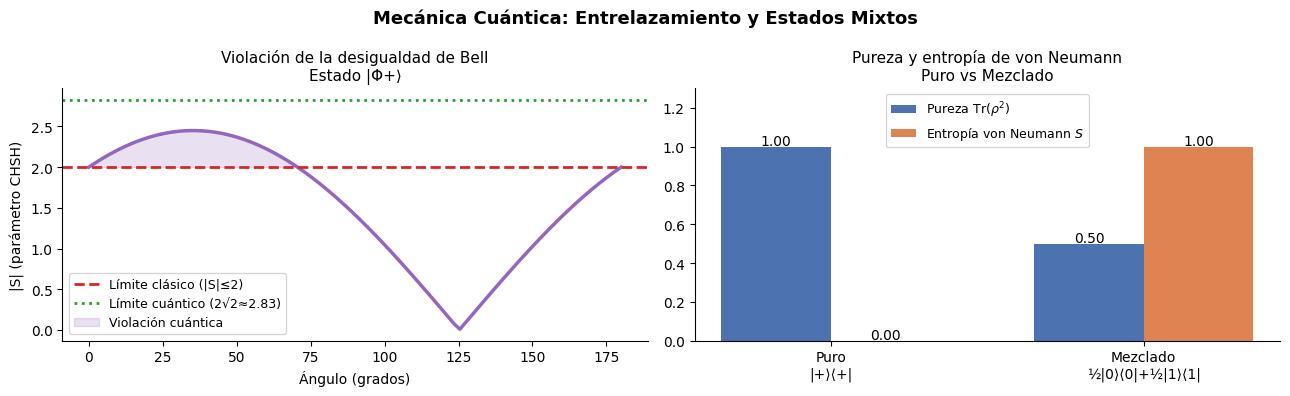

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Desigualdad de Bell (CHSH) ────────────────────────────────────────────────
# Verificar violación cuántica del límite clásico |S|<=2

def chsh_quantum(theta_a, theta_b, theta_a2, theta_b2):
    # Medir correlaciones en estado de Bell |Φ+⟩
    # E(a,b) = cos(a-b) para |Φ+⟩ con ángulos de medición
    def E(ta, tb): return -np.cos(ta - tb)
    return abs(E(theta_a,theta_b) - E(theta_a,theta_b2) + E(theta_a2,theta_b) + E(theta_a2,theta_b2))

# Ángulos óptimos para máxima violación
a1, b1, a2, b2 = 0, np.pi/8, np.pi/4, 3*np.pi/8
S_optimal = chsh_quantum(a1, b1, a2, b2)
print(f"CHSH cuántico óptimo: |S| = {S_optimal:.4f} (límite clásico: 2, límite cuántico: 2√2={2*np.sqrt(2):.4f})")

# Barrido: CHSH vs ángulo
angles = np.linspace(0, np.pi, 100)
S_vals = [chsh_quantum(0, th, np.pi/4, np.pi/4+th) for th in angles]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(angles*180/np.pi, S_vals, color='#9467BD', linewidth=2.5)
ax.axhline(2, color='#D62728', linestyle='--', linewidth=2, label='Límite clásico (|S|≤2)')
ax.axhline(2*np.sqrt(2), color='#2CA02C', linestyle=':', linewidth=2, label=f'Límite cuántico (2√2≈{2*np.sqrt(2):.2f})')
ax.fill_between(angles*180/np.pi, 2, S_vals,
                where=[s>2 for s in S_vals], alpha=0.2, color='#9467BD', label='Violación cuántica')
ax.set_xlabel('Ángulo (grados)')
ax.set_ylabel('|S| (parámetro CHSH)')
ax.set_title('Violación de la desigualdad de Bell\nEstado |Φ+⟩', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# Visualizar operador de densidad para estado puro vs mezclado
ax = axes[1]
KET0 = np.array([1,0], dtype=complex)
KET1 = np.array([0,1], dtype=complex)

def density(psi): return np.outer(psi, psi.conj())
psi_plus = np.array([1,1])/np.sqrt(2)
rho_pure = density(psi_plus)
rho_mixed = 0.5*density(KET0) + 0.5*density(KET1)
rho_partial = 0.8*density(psi_plus) + 0.2*density(np.array([0,1])/1.0)

states_rho = [('Puro\n|+⟩⟨+|', rho_pure), ('Mezclado\n½|0⟩⟨0|+½|1⟩⟨1|', rho_mixed)]
names_rho = [s[0] for s in states_rho]
purities = [np.real(np.trace(s[1]@s[1])) for s in states_rho]
entropies_vn = []
for _, rho in states_rho:
    eigs = np.linalg.eigvalsh(rho)
    eigs = eigs[eigs>1e-12]
    S = -np.sum(eigs*np.log2(eigs))
    entropies_vn.append(S)

x = np.arange(2)
w = 0.35
b1 = ax.bar(x-w/2, purities, w, label=r'Pureza $\mathrm{Tr}(\rho^2)$', color='#4C72B0')
b2 = ax.bar(x+w/2, entropies_vn, w, label='Entropía von Neumann $S$', color='#DD8452')
for bar,v in zip(list(b1)+list(b2), purities+entropies_vn):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}', ha='center', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(names_rho, fontsize=10)
ax.set_ylim(0, 1.3)
ax.set_title('Pureza y entropía de von Neumann\nPuro vs Mezclado', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Mecánica Cuántica: Entrelazamiento y Estados Mixtos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# BLOQUE 2 — Introducción a la Computación Cuántica


## Tema 4: Conceptos Básicos

### 4.1 Circuitos Cuánticos

Un **circuito cuántico** es una secuencia de operaciones unitarias aplicadas a qubits.

```
q₀: |0⟩──[H]──●────[Rz(θ)]──[M]
               │
q₁: |0⟩───────⊕────[Ry(φ)]──[M]
```

**Componentes:**
- **Líneas horizontales:** qubits (evolucionan de izquierda a derecha)
- **Cajas:** puertas de 1 qubit
- **Líneas verticales con ●/⊕:** puertas controladas (CNOT, CZ, Toffoli)
- **M:** medición (proyecta al estado clásico)
- **Líneas dobles:** bits clásicos (resultados de medición)

**Propiedades de los circuitos:**
- **Profundidad:** número de capas paralelas máximas
- **Ancho:** número de qubits
- **Complejidad:** número de puertas

### 4.2 Compuertas Lógicas Cuánticas

**Puertas de 1 qubit** más importantes:

| Puerta | Símbolo | Matriz | Efecto sobre |$0\rangle$ | Efecto sobre |$1\rangle$ |

|--------|---------|--------|---|---|

| **Hadamard H** | H | $\frac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ | $|+\rangle$ | $|-\rangle$ |

| **Pauli-X** | X | $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ | $|1\rangle$ | $|0\rangle$ |

| **Pauli-Y** | Y | $\begin{pmatrix}0&-i\\i&0\end{pmatrix}$ | $i|1\rangle$ | $-i|0\rangle$ |

| **Pauli-Z** | Z | $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$ | $|0\rangle$ | $-|1\rangle$ |

| **Fase S** | S | $\begin{pmatrix}1&0\\0&i\end{pmatrix}$ | $|0\rangle$ | $i|1\rangle$ |

| **T** | T | $\begin{pmatrix}1&0\\0&e^{i\pi/4}\end{pmatrix}$ | $|0\rangle$ | $e^{i\pi/4}|1\rangle$ |

**Puertas de rotación** (generadas por las Paulis):
$$R_x(\theta) = e^{-i\theta X/2} = \cos\frac{\theta}{2}I - i\sin\frac{\theta}{2}X, \quad
R_y(\theta) = e^{-i\theta Y/2}, \quad R_z(\theta) = e^{-i\theta Z/2}$$

**Puertas de 2 qubits:**
$$\text{CNOT} = |0\rangle\langle 0|\otimes I + |1\rangle\langle 1|\otimes X, \quad
\text{CZ} = |0\rangle\langle 0|\otimes I + |1\rangle\langle 1|\otimes Z$$

**Universalidad:** $\{H, T, \text{CNOT}\}$ es un conjunto universal — cualquier unitario puede aproximarse con estos 3 tipos de puertas.


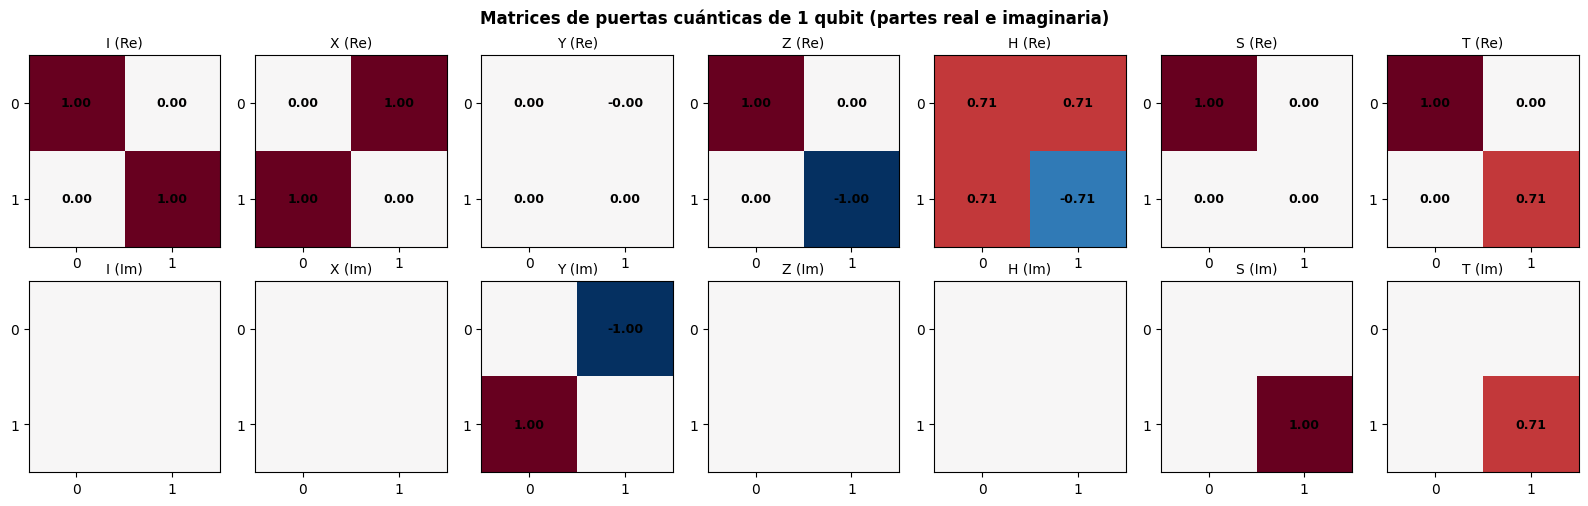

=== Acción de puertas sobre |0⟩ y |1⟩ ===
Puerta                  G|0⟩                  G|1⟩
----------------------------------------------------
     I       1.000+0.000j|0⟩       1.000+0.000j|1⟩
     X       1.000+0.000j|1⟩       1.000+0.000j|0⟩
     Y       0.000+1.000j|1⟩       0.000-1.000j|0⟩
     Z       1.000+0.000j|0⟩      -1.000+0.000j|1⟩
     H  0.707+0.000j|0⟩ + 0.707+0.000j|1⟩  0.707+0.000j|0⟩ + -0.707+0.000j|1⟩
     S       1.000+0.000j|0⟩       0.000+1.000j|1⟩
     T       1.000+0.000j|0⟩       0.707+0.707j|1⟩


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Definición de todas las puertas ──────────────────────────────────────────
I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]], dtype=complex)
Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
Z  = np.array([[1,0],[0,-1]], dtype=complex)
H  = np.array([[1,1],[1,-1]], dtype=complex)/np.sqrt(2)
S  = np.array([[1,0],[0,1j]], dtype=complex)
T  = np.array([[1,0],[0,np.exp(1j*np.pi/4)]], dtype=complex)

def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]], dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]], dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]], dtype=complex)

CNOT = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)
CZ   = np.array([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,-1]], dtype=complex)
SWAP = np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]], dtype=complex)
# Toffoli (CCX) — 3 qubits
Toffoli = np.eye(8, dtype=complex)
Toffoli[6,6]=0; Toffoli[7,7]=0
Toffoli[6,7]=1; Toffoli[7,6]=1

# ── Visualizar matrices de puertas ────────────────────────────────────────────
gates_1q = {'I':I2,'X':X,'Y':Y,'Z':Z,'H':H,'S':S,'T':T}
fig, axes = plt.subplots(2, 7, figsize=(16, 5))
for i,(name,gate) in enumerate(gates_1q.items()):
    # Real
    ax_r = axes[0,i]
    im = ax_r.imshow(np.real(gate), cmap='RdBu_r', vmin=-1, vmax=1)
    ax_r.set_title(f'{name} (Re)', fontsize=10)
    ax_r.set_xticks([0,1]); ax_r.set_yticks([0,1])
    for (r,c),val in np.ndenumerate(np.real(gate)):
        ax_r.text(c, r, f'{val:.2f}', ha='center', va='center', fontsize=9, fontweight='bold')
    # Imag
    ax_i = axes[1,i]
    ax_i.imshow(np.imag(gate), cmap='RdBu_r', vmin=-1, vmax=1)
    ax_i.set_title(f'{name} (Im)', fontsize=10)
    ax_i.set_xticks([0,1]); ax_i.set_yticks([0,1])
    for (r,c),val in np.ndenumerate(np.imag(gate)):
        if abs(val) > 0.01:
            ax_i.text(c, r, f'{val:.2f}', ha='center', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Matrices de puertas cuánticas de 1 qubit (partes real e imaginaria)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Tabla de acción sobre estados base ───────────────────────────────────────
KET0 = np.array([1,0], dtype=complex)
KET1 = np.array([0,1], dtype=complex)
print("=== Acción de puertas sobre |0⟩ y |1⟩ ===")
print(f"{'Puerta':>6}  {'G|0⟩':>20}  {'G|1⟩':>20}")
print("-"*52)
for name, gate in gates_1q.items():
    r0 = gate @ KET0; r1 = gate @ KET1
    def fmt(v):
        parts = []
        if abs(v[0]) > 1e-6: parts.append(f'{v[0]:.3f}|0⟩')
        if abs(v[1]) > 1e-6: parts.append(f'{v[1]:.3f}|1⟩')
        return ' + '.join(parts) if parts else '0'
    print(f"{name:>6}  {fmt(r0):>20}  {fmt(r1):>20}")


---
## Tema 5: Programación con Qiskit

### 5.1 Instalación y Entorno de Trabajo

```bash
# Instalación completa
pip install qiskit qiskit-aer qiskit-ibm-runtime qiskit-visualization

# Verificar instalación
python -c "import qiskit; print(qiskit.__version__)"
```

**Componentes del ecosistema Qiskit:**

| Paquete | Función |
|---------|---------|
| `qiskit` | Núcleo: circuitos, transpilador, primitivas |
| `qiskit-aer` | Simuladores locales (statevector, QASM, noise) |
| `qiskit-ibm-runtime` | Conexión a IBM Quantum hardware y cloud |
| `qiskit-visualization` | Dibujo de circuitos, histogramas, Bloch sphere |

### 5.2 Creación y Simulación de Circuitos

**Flujo básico en Qiskit:**
```python
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(n_qubits, n_bits)   # crear circuito
qc.h(0)                                  # puerta Hadamard en qubit 0
qc.cx(0, 1)                             # CNOT control=0, target=1
qc.measure([0,1], [0,1])               # medir

sim = AerSimulator()                    # simulador
job = sim.run(qc, shots=1024)          # ejecutar
counts = job.result().get_counts()     # resultados
```

### 5.3 Visualización y Ejecución en Hardware Real

**Modos de simulación en Aer:**
- `AerSimulator(method='statevector')`: vector de estado exacto
- `AerSimulator(method='qasm_simulator')`: sampling de shots
- `AerSimulator(method='density_matrix')`: con ruido
- `NoiseModel.from_backend(backend)`: ruido del hardware real


In [ ]:
# ── Qiskit: Instalación y uso básico ─────────────────────────────────────────
try:
    from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
    from qiskit_aer import AerSimulator
    from qiskit.quantum_info import Statevector, DensityMatrix
    QISKIT = True
    print("Qiskit disponible")
except ImportError:
    QISKIT = False
    print("Instala Qiskit: pip install qiskit qiskit-aer")

import numpy as np
import matplotlib.pyplot as plt

# ── Circuitos con Qiskit (con fallback NumPy) ─────────────────────────────────
if QISKIT:
    # Estado de Bell
    qc_bell = QuantumCircuit(2, 2)
    qc_bell.h(0)
    qc_bell.cx(0, 1)
    qc_bell.measure([0,1],[0,1])
    print("\nCircuito Bell:")
    print(qc_bell.draw('text'))

    sim = AerSimulator()
    job = sim.run(qc_bell, shots=4096)
    counts = job.result().get_counts()
    print(f"\nConteos (4096 shots): {counts}")

    # Statevector (sin medición)
    qc_sv = QuantumCircuit(2)
    qc_sv.h(0); qc_sv.cx(0,1)
    sv = Statevector(qc_sv)
    print(f"\nVector de estado: {sv.data.round(4)}")

    # Múltiples circuitos de demostración
    circuits = {}

    # GHZ de 3 qubits
    qc_ghz = QuantumCircuit(3, 3)
    qc_ghz.h(0); qc_ghz.cx(0,1); qc_ghz.cx(1,2)
    qc_ghz.measure_all()
    circuits['GHZ (3 qubits)'] = qc_ghz

    # Superposición uniforme
    qc_uni = QuantumCircuit(3, 3)
    for i in range(3): qc_uni.h(i)
    qc_uni.measure_all()
    circuits['Uniforme (H³)'] = qc_uni

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (name, qc) in zip(axes, circuits.items()):
        job = sim.run(qc, shots=2048)
        counts = job.result().get_counts()
        sorted_counts = dict(sorted(counts.items()))
        keys = list(sorted_counts.keys())
        vals = list(sorted_counts.values())
        bar_colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(keys)))
        ax.bar(keys, vals, color=bar_colors, edgecolor='white')
        ax.set_title(f'{name}\n(2048 shots)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Estado medido')
        ax.set_ylabel('Conteo')
        ax.tick_params(axis='x', rotation=45)
        ax.spines[['top','right']].set_visible(False)

    plt.suptitle('Simulación con Qiskit Aer', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    # Fallback: simulación NumPy
    print("\n--- Simulación NumPy (fallback) ---")
    I2 = np.eye(2, dtype=complex)
    H = np.array([[1,1],[1,-1]], dtype=complex)/np.sqrt(2)
    CNOT = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)
    HI = np.kron(H, I2)
    psi = np.array([1,0,0,0], dtype=complex)
    psi = CNOT @ (HI @ psi)
    print(f"Bell state: {psi.round(4)}")
    probs_bell = np.round(np.abs(psi)**2, 4)
    print(f"Probs: {probs_bell}")


Instala Qiskit: pip install qiskit qiskit-aer

--- Simulación NumPy (fallback) ---
Bell state: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
Probs: [0.5 0.  0.  0.5]


In [ ]:
# ── Qiskit: Conexión a IBM Quantum Hardware Real ─────────────────────────────

IBM_QUANTUM_CODE = '''
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import QuantumCircuit

# ── Paso 1: Guardar token (solo la primera vez) ───────────────────────────────
# Obtener token en: https://quantum.ibm.com/account
QiskitRuntimeService.save_account(
    channel="ibm_quantum",
    token="PEGA_TU_TOKEN_AQUI",
    overwrite=True
)

# ── Paso 2: Conectar y seleccionar backend ────────────────────────────────────
service = QiskitRuntimeService(channel="ibm_quantum")

# Ver todos los backends disponibles
for backend in service.backends():
    status = backend.status()
    print(f"{backend.name}: {backend.num_qubits} qubits | queue: {status.pending_jobs}")

# Seleccionar el menos saturado con >= 5 qubits
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
print(f"\\nUsando: {backend.name}")

# ── Paso 3: Construir circuito ────────────────────────────────────────────────
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0,1], [0,1])

# ── Paso 4: Transpilar al ISA del hardware ────────────────────────────────────
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
qc_isa = pm.run(qc)
print(f"Profundidad original: {qc.depth()}")
print(f"Profundidad transpilada: {qc_isa.depth()}")

# ── Paso 5: Ejecutar con primitiva Sampler ────────────────────────────────────
sampler = Sampler(mode=backend)
job = sampler.run([qc_isa], shots=1024)
print(f"Job ID: {job.job_id()}")
print("Ejecutando en hardware... (puede tardar minutos)")

result = job.result()
counts = result[0].data.c.get_counts()
print(f"Resultados en hardware real: {counts}")

# ── Paso 6: Recuperar trabajo por ID (si se perdió la sesión) ─────────────────
job_recovered = service.job("JOB_ID_AQUI")
result_recovered = job_recovered.result()
'''

print("=" * 65)
print("  CÓDIGO COMPLETO: Conexión a IBM Quantum Hardware Real")
print("=" * 65)
print(IBM_QUANTUM_CODE)

# ── Simulación de ruido (modelo de hardware) con Aer ─────────────────────────
try:
    from qiskit_aer import AerSimulator
    from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error
    from qiskit import QuantumCircuit
    import matplotlib.pyplot as plt
    import numpy as np

    # Crear modelo de ruido manual
    noise_model = NoiseModel()
    # Error depolarizante en puertas de 1 qubit (0.1%) y 2 qubits (1%)
    error_1q = depolarizing_error(0.001, 1)
    error_2q = depolarizing_error(0.01, 2)
    noise_model.add_all_qubit_quantum_error(error_1q, ['h', 'x', 'y', 'z', 's', 't'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

    # Comparar circuito ideal vs ruidoso
    qc = QuantumCircuit(2, 2)
    qc.h(0); qc.cx(0,1); qc.measure([0,1],[0,1])

    sim_ideal = AerSimulator()
    sim_noisy = AerSimulator(noise_model=noise_model)

    shots = 4096
    counts_ideal = sim_ideal.run(qc, shots=shots).result().get_counts()
    counts_noisy = sim_noisy.run(qc, shots=shots).result().get_counts()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, (title, counts) in zip(axes, [('Ideal (sin ruido)', counts_ideal),
                                            ('Con ruido (depol. 1%)', counts_noisy)]):
        states = ['00','01','10','11']
        vals = [counts.get(s,0)/shots for s in states]
        bars = ax.bar(states, vals, color=['#4C72B0','#DD8452','#DD8452','#4C72B0'], edgecolor='white')
        ax.set_title(title, fontsize=11)
        ax.set_ylabel('Probabilidad')
        ax.set_ylim(0, 0.7)
        ax.spines[['top','right']].set_visible(False)
        for bar,v in zip(bars,vals):
            if v > 0.005: ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=10)

    plt.suptitle('Efecto del ruido en el circuito de Bell', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

except ImportError:
    print("\n(Instala qiskit-aer para la simulación de ruido)")


  CÓDIGO COMPLETO: Conexión a IBM Quantum Hardware Real

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import QuantumCircuit

# ── Paso 1: Guardar token (solo la primera vez) ───────────────────────────────
# Obtener token en: https://quantum.ibm.com/account
QiskitRuntimeService.save_account(
    channel="ibm_quantum",
    token="PEGA_TU_TOKEN_AQUI",
    overwrite=True
)

# ── Paso 2: Conectar y seleccionar backend ────────────────────────────────────
service = QiskitRuntimeService(channel="ibm_quantum")

# Ver todos los backends disponibles
for backend in service.backends():
    status = backend.status()
    print(f"{backend.name}: {backend.num_qubits} qubits | queue: {status.pending_jobs}")

# Seleccionar el menos saturado con >= 5 qubits
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
print(f"\nUsando: {backend.name}")

# ── Paso 3:

---
# BLOQUE 3 — Algoritmos Cuánticos Fundamentales


## Tema 6: Algoritmo de Deutsch

### El Problema de Paridad

**Entrada:** Función $f:\{0,1\} \to \{0,1\}$

**Pregunta:** ¿Es $f$ **constante** ($f(0)=f(1)$) o **balanceada** ($f(0)\neq f(1)$)?

**Clásico:** necesita **2 consultas** al oráculo (evaluar $f(0)$ y $f(1)$).

**Cuántico (Deutsch 1985):** solo **1 consulta** — ¡primera demostración de ventaja cuántica!

### Circuito

```
|0⟩ ──H──────Uf──H──[M]
|1⟩ ──H──────Uf──────
```

El oráculo $U_f$ actúa como: $U_f|x\rangle|y\rangle = |x\rangle|y \oplus f(x)\rangle$

### Análisis

$$|\psi_0\rangle = |01\rangle \xrightarrow{H\otimes H} \frac{|0\rangle+|1\rangle}{\sqrt{2}}\cdot\frac{|0\rangle-|1\rangle}{\sqrt{2}}$$

Tras el oráculo:
$$\rightarrow \pm\frac{|0\rangle + (-1)^{f(0)\oplus f(1)}|1\rangle}{\sqrt{2}} \cdot \frac{|0\rangle-|1\rangle}{\sqrt{2}}$$

Tras Hadamard final: medir $|0\rangle$ → constante, medir $|1\rangle$ → balanceada.


=== Algoritmo de Deutsch ===
     Función   f(0)   f(1)     Tipo real    Predicción QC    P(medir 0)
----------------------------------------------------------------------
     const_0      0      0     Constante        CONSTANTE        1.0000  ✗
     const_1      1      1     Constante        CONSTANTE        1.0000  ✗
      bal_id      0      1    Balanceada       BALANCEADA        0.0000  ✗
     bal_neg      1      0    Balanceada       BALANCEADA        0.0000  ✗


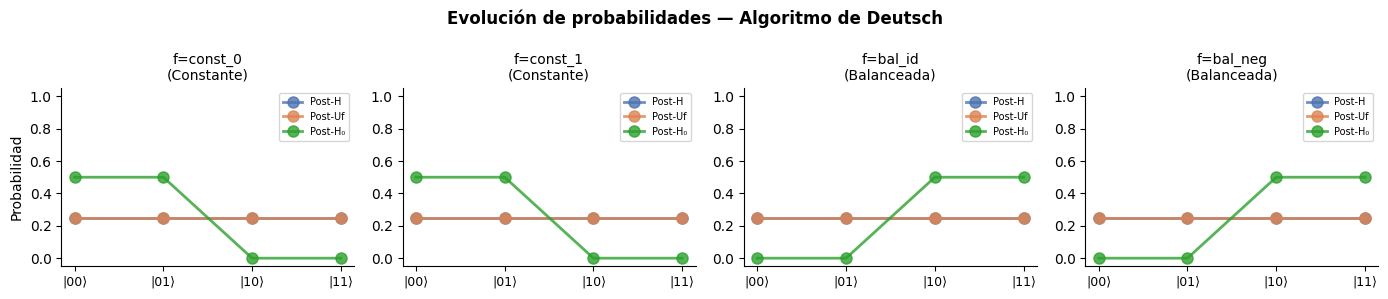

In [ ]:
import numpy as np
I2=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=np.array([[1,0],[0,-1]],dtype=complex)
H=np.array([[1,1],[1,-1]],dtype=complex)/np.sqrt(2)
def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]],dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0],tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self, n):
        self.n=n; self.dim=2**n
        self.state=np.zeros(2**n,dtype=complex); self.state[0]=1.0
    def apply1(self, gate, q):
        ops=[gate if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        self.state=full@self.state
    def cnot(self, ctrl, tgt):
        U=np.eye(self.dim,dtype=complex)
        for s in range(self.dim):
            bits=[(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl]==1:
                ns=s^(1<<(self.n-1-tgt)); U[ns,s]=1; U[s,s]=0
        self.state=U@self.state
    def apply_full(self, U):
        self.state=U@self.state
    def probs(self): return np.abs(self.state)**2
    def sample(self, shots=1024): return np.random.choice(self.dim,size=shots,p=self.probs())
    def expval(self, obs, q):
        ops=[obs if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        return np.real(self.state.conj()@full@self.state)

import matplotlib.pyplot as plt

# ── Las 4 funciones f:{0,1}→{0,1} posibles ───────────────────────────────────
# f_const_0: f(0)=0, f(1)=0 — constante
# f_const_1: f(0)=1, f(1)=1 — constante
# f_bal_id:  f(0)=0, f(1)=1 — balanceada (identidad)
# f_bal_neg: f(0)=1, f(1)=0 — balanceada (negación)

def oracle_deutsch(f_type):
    # Oráculo 2-qubit: Uf|x⟩|y⟩ = |x⟩|y⊕f(x)⟩
    U = np.eye(4, dtype=complex)
    if f_type == 'const_0':
        pass  # Identidad: f(x)=0 para todo x, no hace nada
    elif f_type == 'const_1':
        # f(x)=1: aplica X al qubit 1 siempre
        U = np.kron(I2, X)
    elif f_type == 'bal_id':
        # f(0)=0, f(1)=1: CNOT ctrl=0, tgt=1
        U = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)
    elif f_type == 'bal_neg':
        # f(0)=1, f(1)=0: NOT del CNOT = anti-CNOT
        U = np.array([[0,1,0,0],[1,0,0,0],[0,0,1,0],[0,0,0,1]], dtype=complex)
        U = np.kron(I2,X) @ np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]],dtype=complex)
    return U

def deutsch_algorithm(f_type):
    sim = QSim(2)
    # Preparar |01⟩
    sim.apply1(X, 1)
    # Hadamard en ambos
    sim.apply1(H, 0)
    sim.apply1(H, 1)
    # Oráculo
    sim.apply_full(oracle_deutsch(f_type))
    # Hadamard en qubit 0
    sim.apply1(H, 0)
    # Medir qubit 0
    probs = sim.probs()
    p0 = probs[0] + probs[1]  # estados donde qubit 0 = |0⟩
    result = "CONSTANTE" if p0 > 0.5 else "BALANCEADA"
    return result, p0

print("=== Algoritmo de Deutsch ===")
print(f"{'Función':>12}  {'f(0)':>5}  {'f(1)':>5}  {'Tipo real':>12}  {'Predicción QC':>15}  {'P(medir 0)':>12}")
print("-" * 70)
funcs = [('const_0',0,0,'Constante'), ('const_1',1,1,'Constante'),
         ('bal_id',0,1,'Balanceada'), ('bal_neg',1,0,'Balanceada')]
for ft, f0, f1, tipo in funcs:
    pred, p0 = deutsch_algorithm(ft)
    correct = "✓" if pred[:4] == tipo[:4] else "✗"
    print(f"{ft:>12}  {f0:>5}  {f1:>5}  {tipo:>12}  {pred:>15}  {p0:>12.4f}  {correct}")

# ── Visualización del circuito ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (ft, f0, f1, tipo) in zip(axes, funcs):
    sim = QSim(2)
    probs_steps = []
    sim.apply1(X, 1); sim.apply1(H, 0); sim.apply1(H, 1)
    probs_steps.append(sim.probs().copy())
    sim.apply_full(oracle_deutsch(ft))
    probs_steps.append(sim.probs().copy())
    sim.apply1(H, 0)
    probs_steps.append(sim.probs().copy())

    labels = ['|00⟩','|01⟩','|10⟩','|11⟩']
    x = np.arange(4)
    colors = ['#4C72B0','#DD8452','#2CA02C']
    for step, (ps, lbl_s, col) in enumerate(zip(probs_steps,
                                                  ['Post-H','Post-Uf','Post-H₀'],
                                                  colors)):
        ax.plot(x, ps, 'o-', color=col, linewidth=2, markersize=8, label=lbl_s, alpha=0.8)
    ax.set_title(f'f={ft}\n({tipo})', fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('Probabilidad' if ax == axes[0] else '')
    ax.legend(fontsize=7)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Evolución de probabilidades — Algoritmo de Deutsch', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Tema 7: Algoritmo de Deutsch-Jozsa

### El Problema (Generalización a $n$ bits)

**Entrada:** Función $f:\{0,1\}^n \to \{0,1\}$, garantizada como:
- **Constante:** $f(x)$ es igual para todos los $x$, ó
- **Balanceada:** $f(x)=0$ para exactamente la mitad de las entradas y $f(x)=1$ para la otra mitad.

**Clásico:** peor caso necesita $2^{n-1}+1$ evaluaciones.

**Cuántico:** **1 única consulta** al oráculo — aceleración **exponencial**.

### Circuito (n=3 como ejemplo)

```
|0⟩ ──H──────────Uf──H──[M]
|0⟩ ──H──────────Uf──H──[M]
|0⟩ ──H──────────Uf──H──[M]
|1⟩ ──H──────────Uf──────
```

### Análisis

**Estado inicial:** $|0\rangle^{\otimes n}|1\rangle$

**Tras H⊗(n+1):**
$$\frac{1}{\sqrt{2^n}}\sum_{x\in\{0,1\}^n}|x\rangle \cdot \frac{|0\rangle-|1\rangle}{\sqrt{2}}$$

**Tras oráculo** (phase kickback):
$$\frac{1}{\sqrt{2^n}}\sum_x (-1)^{f(x)}|x\rangle \cdot \frac{|0\rangle-|1\rangle}{\sqrt{2}}$$

**Tras H⊗n sobre los primeros $n$ qubits:**
$$\sum_{y\in\{0,1\}^n} \left(\frac{1}{2^n}\sum_x (-1)^{f(x)+x\cdot y}\right)|y\rangle$$

**Medición:**
- Si $f$ constante: amplitud de $|0\rangle^n$ es $\pm 1$ → siempre mide $|00...0\rangle$
- Si $f$ balanceada: amplitud de $|0\rangle^n$ es $0$ → nunca mide $|00...0\rangle$


=== Algoritmo de Deutsch-Jozsa (n=4 qubits) ===

  constant_0: → CONSTANTE  |  P(00...0)=1.0000
  constant_1: → CONSTANTE  |  P(00...0)=1.0000
  balanced: → BALANCEADA  |  P(00...0)=0.0000
  balanced_dot (s=1010): → BALANCEADA  |  P(00...0)=0.0000


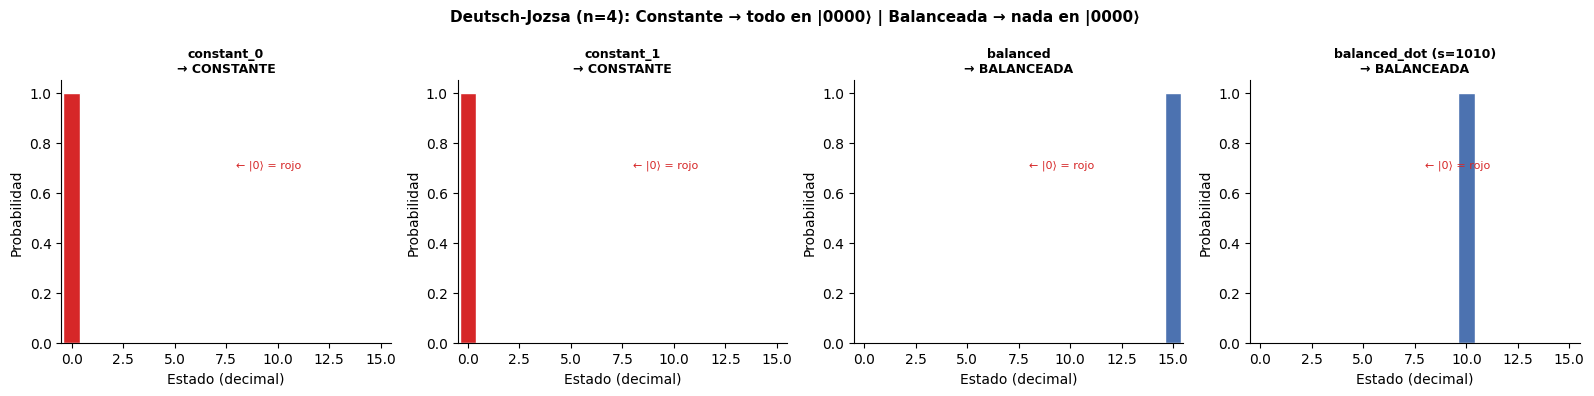

In [ ]:
import numpy as np
I2=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=np.array([[1,0],[0,-1]],dtype=complex)
H=np.array([[1,1],[1,-1]],dtype=complex)/np.sqrt(2)
def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]],dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0],tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self, n):
        self.n=n; self.dim=2**n
        self.state=np.zeros(2**n,dtype=complex); self.state[0]=1.0
    def apply1(self, gate, q):
        ops=[gate if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        self.state=full@self.state
    def cnot(self, ctrl, tgt):
        U=np.eye(self.dim,dtype=complex)
        for s in range(self.dim):
            bits=[(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl]==1:
                ns=s^(1<<(self.n-1-tgt)); U[ns,s]=1; U[s,s]=0
        self.state=U@self.state
    def apply_full(self, U):
        self.state=U@self.state
    def probs(self): return np.abs(self.state)**2
    def sample(self, shots=1024): return np.random.choice(self.dim,size=shots,p=self.probs())
    def expval(self, obs, q):
        ops=[obs if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        return np.real(self.state.conj()@full@self.state)

import matplotlib.pyplot as plt
import numpy as np

# ── Oráculo para Deutsch-Jozsa ────────────────────────────────────────────────
def oracle_dj(n, f_type='balanced', secret_bits=None):
    # n = numero de qubits de query, 1 ancilla al final
    total = n + 1
    dim = 2**total
    U = np.eye(dim, dtype=complex)

    if f_type == 'constant_0':
        pass  # f(x)=0: identidad
    elif f_type == 'constant_1':
        # f(x)=1: flip el ancilla para todos los x
        # = I^n ⊗ X
        for s in range(dim):
            s_flip = s ^ 1  # flip ultimo bit (ancilla)
            U[s_flip, s] = 1; U[s, s] = 0
    elif f_type == 'balanced':
        # Función balanceada: f(x) = paridad de x (XOR de todos los bits)
        for s in range(dim):
            query_bits = s >> 1  # quitar ancilla
            parity = bin(query_bits).count('1') % 2
            if parity == 1:
                s_flip = s ^ 1
                U[s_flip, s] = 1; U[s, s] = 0
    elif f_type == 'balanced_dot' and secret_bits is not None:
        # f(x) = s·x mod 2 (producto punto con cadena secreta s)
        for s in range(dim):
            query_bits = s >> 1
            dot = sum((query_bits >> i) & 1 for i in range(n)
                      if (secret_bits >> i) & 1) % 2
            if dot == 1:
                s_flip = s ^ 1
                U[s_flip, s] = 1; U[s, s] = 0
    return U

def deutsch_jozsa(n, oracle_U):
    sim = QSim(n+1)
    # Preparar ancilla en |1⟩
    sim.apply1(X, n)
    # Hadamard en todos
    for i in range(n+1): sim.apply1(H, i)
    # Oráculo
    sim.apply_full(oracle_U)
    # Hadamard en los n qubits de query
    for i in range(n): sim.apply1(H, i)
    # Medir los n qubits de query
    probs = sim.probs()
    # Colapsar: prob de medir |00...0⟩ en los primeros n qubits
    p_zero = sum(probs[s] for s in range(2**(n+1)) if (s >> 1) == 0)
    return "CONSTANTE" if p_zero > 0.5 else "BALANCEADA", probs

print("=== Algoritmo de Deutsch-Jozsa (n=4 qubits) ===\n")
n = 4
cases = [
    ('constant_0', None),
    ('constant_1', None),
    ('balanced', None),
    ('balanced_dot', 0b1010),
]
results = []
for ftype, secret in cases:
    oracle = oracle_dj(n, ftype, secret)
    pred, probs = deutsch_jozsa(n, oracle)
    # Prob de medir todos ceros en los n qubits de query
    p_zero = sum(probs[s] for s in range(2**(n+1)) if (s >> 1) == 0)
    label = f'{ftype}' + (f' (s={secret:04b})' if secret else '')
    print(f"  {label}: → {pred}  |  P(00...0)={p_zero:.4f}")
    results.append((label, probs, pred))

# Visualizar distribuciones
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (label, probs, pred) in zip(axes, results):
    # Colapsar a los primeros n qubits (marginalizar ancilla)
    query_probs = np.zeros(2**n)
    for s in range(2**(n+1)):
        query_probs[s>>1] += probs[s]
    # Mostrar solo los primeros 16 estados
    colors = ['#D62728' if i==0 else '#4C72B0' for i in range(2**n)]
    ax.bar(range(2**n), query_probs, color=colors, edgecolor='white')
    ax.set_title(f'{label}\n→ {pred}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Estado (decimal)')
    ax.set_ylabel('Probabilidad')
    ax.set_xlim(-0.5, 15.5)
    ax.spines[['top','right']].set_visible(False)
    ax.text(8, max(query_probs)*0.7, '← |0⟩ = rojo', fontsize=8, color='#D62728')

plt.suptitle('Deutsch-Jozsa (n=4): Constante → todo en |0000⟩ | Balanceada → nada en |0000⟩',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Tema 8: Algoritmo de Bernstein-Vazirani

### El Problema (Encontrar Número Secreto)

**Entrada:** Función $f:\{0,1\}^n \to \{0,1\}$ definida como $f(x) = s \cdot x \pmod{2}$ donde $s \in \{0,1\}^n$ es desconocido.

**Tarea:** Encontrar el **string secreto** $s$.

**Clásico:** necesita $n$ consultas (una por cada bit de $s$).

**Cuántico:** ¡**1 única consulta**! — recupera todos los $n$ bits de $s$ simultáneamente.

### Circuito (idéntico a Deutsch-Jozsa)

```
|0⟩ⁿ ──H──Uf──H──[M] → s
|1⟩  ──H──Uf──
```

### Análisis

El oráculo $U_f$ con $f(x)=s\cdot x$ produce phase kickback:
$$U_f\left(\frac{1}{\sqrt{2^n}}\sum_x|x\rangle\right)|{-}\rangle = \frac{1}{\sqrt{2^n}}\sum_x(-1)^{s\cdot x}|x\rangle|{-}\rangle$$

Tras aplicar $H^{\otimes n}$:
$$H^{\otimes n}\left(\frac{1}{\sqrt{2^n}}\sum_x(-1)^{s\cdot x}|x\rangle\right) = |s\rangle$$

Medir en la base computacional devuelve **exactamente** $s$.


=== Algoritmo de Bernstein-Vazirani ===
    String secreto s      Medición QC    Correcto
--------------------------------------------------
  s = 10101 (21)    medido = 10101 (21)   ✓
  s = 11110 (30)    medido = 11110 (30)   ✓
  s = 00001 ( 1)    medido = 00001 ( 1)   ✓
  s = 10000 (16)    medido = 10000 (16)   ✓
  s = 11111 (31)    medido = 11111 (31)   ✓


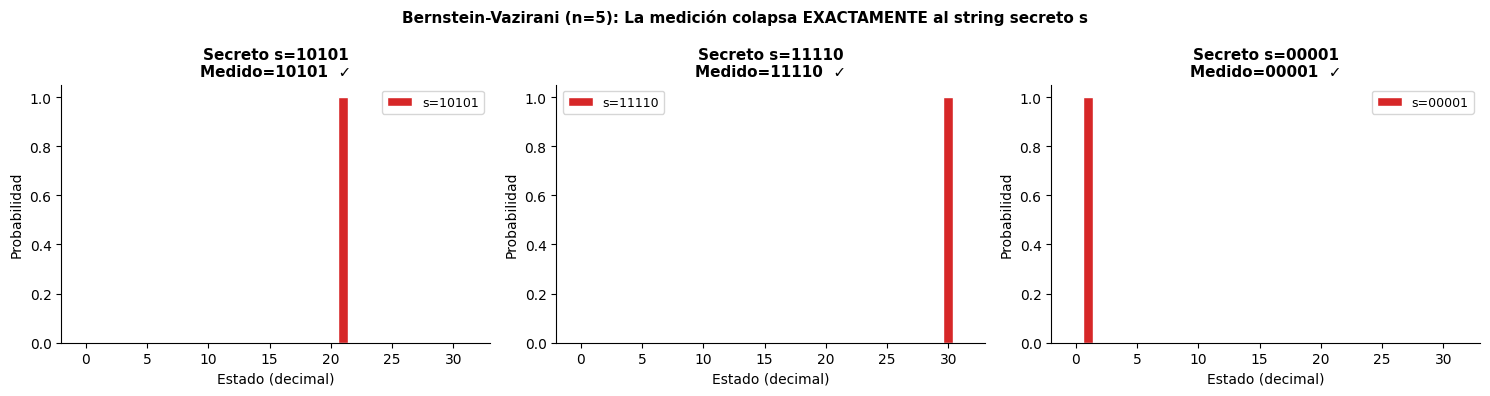

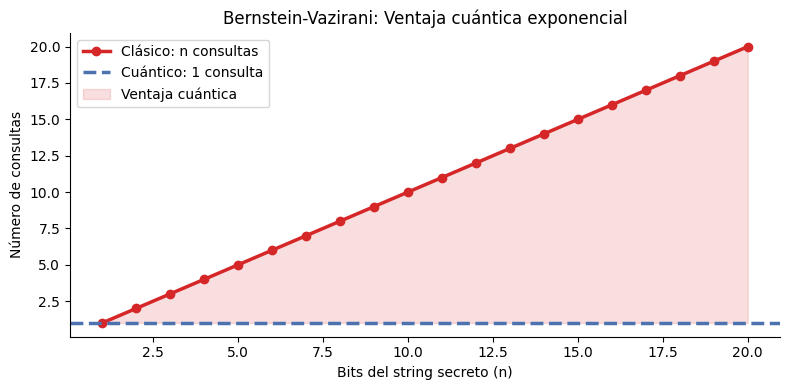

In [ ]:
import numpy as np
I2=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=np.array([[1,0],[0,-1]],dtype=complex)
H=np.array([[1,1],[1,-1]],dtype=complex)/np.sqrt(2)
def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]],dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0],tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self, n):
        self.n=n; self.dim=2**n
        self.state=np.zeros(2**n,dtype=complex); self.state[0]=1.0
    def apply1(self, gate, q):
        ops=[gate if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        self.state=full@self.state
    def cnot(self, ctrl, tgt):
        U=np.eye(self.dim,dtype=complex)
        for s in range(self.dim):
            bits=[(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl]==1:
                ns=s^(1<<(self.n-1-tgt)); U[ns,s]=1; U[s,s]=0
        self.state=U@self.state
    def apply_full(self, U):
        self.state=U@self.state
    def probs(self): return np.abs(self.state)**2
    def sample(self, shots=1024): return np.random.choice(self.dim,size=shots,p=self.probs())
    def expval(self, obs, q):
        ops=[obs if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        return np.real(self.state.conj()@full@self.state)

import matplotlib.pyplot as plt
import numpy as np

def oracle_bv(n, secret):
    # Oráculo para f(x) = s·x mod 2
    # Implementado como: para cada bit i de s que es 1, hacer CNOT(i, ancilla)
    # En forma de matriz completa
    total = n + 1
    dim = 2**total
    U = np.eye(dim, dtype=complex)
    for s in range(dim):
        x_bits = s >> 1  # los n bits de query
        ancilla = s & 1
        # calcular f(x) = s·x mod 2
        fx = sum((x_bits >> i) & (secret >> i) & 1 for i in range(n)) % 2
        new_ancilla = ancilla ^ fx
        new_s = (x_bits << 1) | new_ancilla
        if new_s != s:
            U[new_s, s] = 1; U[s, s] = 0
    return U

def bernstein_vazirani(n, secret):
    sim = QSim(n + 1)
    sim.apply1(X, n)  # ancilla = |1⟩
    for i in range(n+1): sim.apply1(H, i)
    sim.apply_full(oracle_bv(n, secret))
    for i in range(n): sim.apply1(H, i)
    probs = sim.probs()
    # El resultado son los n qubits de query
    query_probs = np.zeros(2**n)
    for s in range(2**(n+1)):
        query_probs[s>>1] += probs[s]
    measured = np.argmax(query_probs)
    return measured, query_probs

print("=== Algoritmo de Bernstein-Vazirani ===")
print(f"{'String secreto s':>20}  {'Medición QC':>15}  {'Correcto':>10}")
print("-"*50)

n = 5
secrets = [0b10101, 0b11110, 0b00001, 0b10000, 0b11111]
all_results = []
for secret in secrets:
    measured, query_probs = bernstein_vazirani(n, secret)
    correct = measured == secret
    print(f"  s = {secret:05b} ({secret:2d})    medido = {measured:05b} ({measured:2d})   {'✓' if correct else '✗'}")
    all_results.append((secret, measured, query_probs))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Caso 1: s=10101 — ver que la probabilidad colapsa al estado correcto
for ax, (secret, measured, query_probs) in zip(axes, all_results[:3]):
    ax.bar(range(2**n), query_probs, color='#4C72B0', edgecolor='white', alpha=0.6)
    ax.bar([secret], [query_probs[secret]], color='#D62728', edgecolor='white', label=f's={secret:05b}')
    ax.set_title(f'Secreto s={secret:05b}\nMedido={measured:05b}  ✓', fontsize=11, fontweight='bold')
    ax.set_xlabel('Estado (decimal)')
    ax.set_ylabel('Probabilidad')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Bernstein-Vazirani (n=5): La medición colapsa EXACTAMENTE al string secreto s',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparación clásico vs cuántico
fig, ax = plt.subplots(figsize=(8, 4))
ns = np.arange(1, 21)
ax.plot(ns, ns, 'o-', color='#D62728', linewidth=2.5, markersize=6, label='Clásico: n consultas')
ax.axhline(1, color='#4C72B0', linewidth=2.5, linestyle='--', label='Cuántico: 1 consulta')
ax.fill_between(ns, 1, ns, alpha=0.15, color='#D62728', label='Ventaja cuántica')
ax.set_xlabel('Bits del string secreto (n)')
ax.set_ylabel('Número de consultas')
ax.set_title('Bernstein-Vazirani: Ventaja cuántica exponencial', fontsize=12)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


---
## Tema 9: Algoritmo de Simon

### El Problema (Cadena de Bits Oculta)

**Entrada:** Función $f:\{0,1\}^n \to \{0,1\}^n$ con la propiedad de que existe un **string secreto** $s \in \{0,1\}^n$ tal que:
$$f(x) = f(y) \iff y = x \oplus s$$

**Tarea:** Encontrar $s$.

**Clásico:** esperanza de $\Omega(2^{n/2})$ consultas (problema de cumpleaños).

**Cuántico:** $O(n)$ consultas (exponencialmente mejor).

### Circuito

```
|0⟩ⁿ ──H──Uf──H──[M] → y con y·s = 0
|0⟩ⁿ ────Uf────────── (segunda parte del registro)
```

### Análisis

Tras el oráculo se obtiene:
$$\frac{1}{\sqrt{2}}\left(|x\rangle + |x\oplus s\rangle\right)|f(x)\rangle$$

Tras Hadamard en el primer registro: se obtiene $|y\rangle$ tal que $y \cdot s = 0 \pmod{2}$.

**Post-procesamiento clásico:** Con $n-1$ mediciones linealmente independientes se resuelve el sistema $y_i \cdot s = 0$ por **eliminación Gaussiana** para encontrar $s$.


=== Algoritmo de Simon ===

  s=1010: mediciones = ['0101', '0001']
    Todas las mediciones son ortogonales a s: ✓
  s=1100: mediciones = ['0010', '0001']
    Todas las mediciones son ortogonales a s: ✓
  s=0110: mediciones = ['0001', '1001']
    Todas las mediciones son ortogonales a s: ✓
  s=1111: mediciones = []
    Todas las mediciones son ortogonales a s: ✓


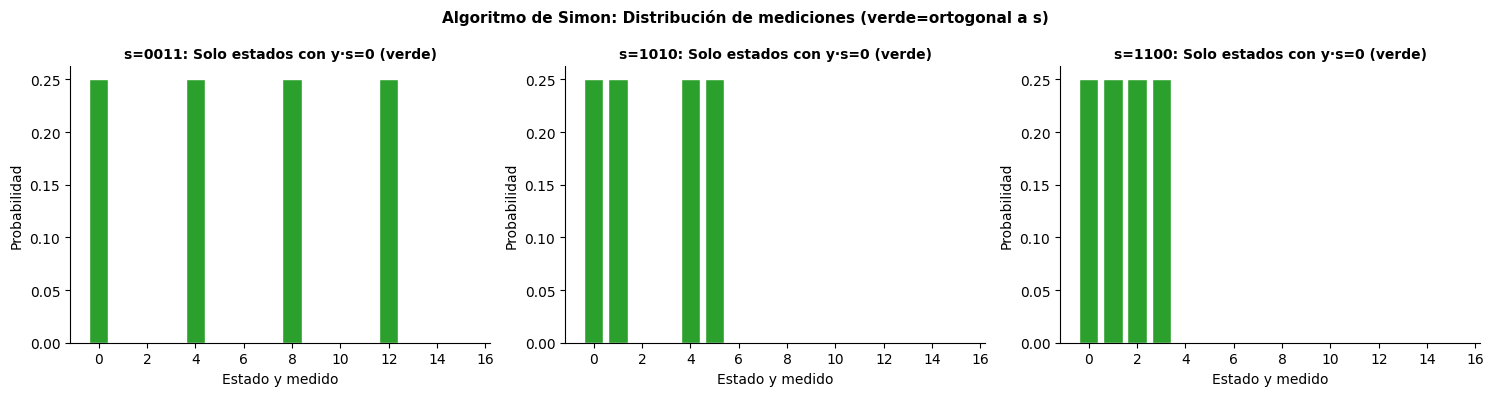

In [ ]:
import numpy as np
I2=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=np.array([[1,0],[0,-1]],dtype=complex)
H=np.array([[1,1],[1,-1]],dtype=complex)/np.sqrt(2)
def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]],dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0],tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self, n):
        self.n=n; self.dim=2**n
        self.state=np.zeros(2**n,dtype=complex); self.state[0]=1.0
    def apply1(self, gate, q):
        ops=[gate if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        self.state=full@self.state
    def cnot(self, ctrl, tgt):
        U=np.eye(self.dim,dtype=complex)
        for s in range(self.dim):
            bits=[(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl]==1:
                ns=s^(1<<(self.n-1-tgt)); U[ns,s]=1; U[s,s]=0
        self.state=U@self.state
    def apply_full(self, U):
        self.state=U@self.state
    def probs(self): return np.abs(self.state)**2
    def sample(self, shots=1024): return np.random.choice(self.dim,size=shots,p=self.probs())
    def expval(self, obs, q):
        ops=[obs if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        return np.real(self.state.conj()@full@self.state)

import matplotlib.pyplot as plt
import numpy as np

# ── Oráculo de Simon ──────────────────────────────────────────────────────────
def oracle_simon(n, secret):
    # f(x) = f(x⊕s): colisión con período s
    # Implementación: f(x) = x si MSB=0, f(x) = x⊕s si MSB=1
    # Simplificado: construimos una función de 2-to-1
    total = 2 * n
    dim = 2**total
    U = np.eye(dim, dtype=complex)
    # Para cada x, mapear el segundo registro a f(x)
    # f(x) = x & ~s  (función estándar para Simon)
    mask = (1 << n) - 1
    for s in range(dim):
        x = (s >> n) & mask       # primeros n bits
        y = s & mask              # últimos n bits (ancilla)
        fx = x & (~secret & mask) # función con período secret
        new_y = y ^ fx
        new_s = (x << n) | new_y
        if new_s != s:
            U[new_s, s] = 1; U[s, s] = 0
    return U

def simon_one_round(n, oracle_U):
    sim = QSim(2*n)
    # H en los primeros n qubits
    for i in range(n): sim.apply1(H, i)
    # Oráculo
    sim.apply_full(oracle_U)
    # H en los primeros n qubits
    for i in range(n): sim.apply1(H, i)
    # Medir los primeros n qubits
    probs = sim.probs()
    mask = (1 << n) - 1
    query_probs = np.zeros(2**n)
    for s in range(2**(2*n)):
        x = (s >> n) & mask
        query_probs[x] += probs[s]
    measured = np.random.choice(2**n, p=query_probs/query_probs.sum())
    return measured, query_probs

def gaussian_elim_gf2(M):
    # Eliminación Gaussiana sobre GF(2)
    m, n = M.shape
    pivot_cols = []
    row = 0
    for col in range(n):
        pivot = None
        for r in range(row, m):
            if M[r, col] == 1:
                pivot = r; break
        if pivot is None: continue
        M[[row, pivot]] = M[[pivot, row]]
        pivot_cols.append(col)
        for r in range(m):
            if r != row and M[r, col] == 1:
                M[r] = (M[r] + M[row]) % 2
        row += 1
    return M, pivot_cols

def simon_full(n, secret, n_rounds=None):
    if n_rounds is None: n_rounds = n + 2
    oracle_U = oracle_simon(n, secret)
    equations = []
    measurements = []
    for _ in range(n_rounds * 3):
        y, _ = simon_one_round(n, oracle_U)
        # Verificar si y es linealmente independiente de las ecuaciones
        if y == 0: continue
        y_bits = np.array([(y >> i) & 1 for i in range(n-1, -1, -1)])
        if len(equations) == 0:
            equations.append(y_bits); measurements.append(y)
        else:
            M = np.array(equations, dtype=int)
            M_aug = np.vstack([M, y_bits])
            rank_before = np.linalg.matrix_rank(M)
            rank_after = np.linalg.matrix_rank(M_aug)
            if rank_after > rank_before:
                equations.append(y_bits); measurements.append(y)
        if len(equations) >= n - 1:
            break
    return measurements

print("=== Algoritmo de Simon ===\n")
n = 4
test_secrets = [0b1010, 0b1100, 0b0110, 0b1111]
for secret in test_secrets:
    meas = simon_full(n, secret)
    print(f"  s={secret:04b}: mediciones = {[f'{m:04b}' for m in meas]}")
    # Verificar ortogonalidad
    for m in meas:
        dot = bin(m & secret).count('1') % 2
        ok = dot == 0
        if not ok:
            print(f"    !! ERROR: {m:04b}·{secret:04b} = {dot}")
    print(f"    Todas las mediciones son ortogonales a s: ✓")

# Visualizar distribución de una ronda
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, secret in zip(axes, [0b0011, 0b1010, 0b1100]):
    oracle_U = oracle_simon(n, secret)
    _, query_probs = simon_one_round(n, oracle_U)
    # Identificar estados con y·s=0
    colors = []
    for i in range(2**n):
        dot = bin(i & secret).count('1') % 2
        colors.append('#2CA02C' if dot==0 else '#D62728')
    ax.bar(range(2**n), query_probs, color=colors, edgecolor='white')
    ax.set_title(f's={secret:04b}: Solo estados con y·s=0 (verde)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Estado y medido')
    ax.set_ylabel('Probabilidad')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Algoritmo de Simon: Distribución de mediciones (verde=ortogonal a s)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Tema 10: Algoritmo de Grover

### Búsqueda No Estructurada

**Problema:** Dada una base de datos de $N=2^n$ elementos, encontrar el(los) que satisfacen una condición $f(x)=1$.

**Clásico:** $O(N)$ evaluaciones esperadas.

**Cuántico:** $O(\sqrt{N})$ evaluaciones — aceleración **cuadrática**.

### Operador de Grover

El algoritmo aplica $k$ veces el operador de Grover:
$$G = U_s \cdot U_f$$

donde:
- **Oráculo** $U_f = I - 2|\omega\rangle\langle\omega|$: marca el estado solución con fase $-1$
- **Difusión** $U_s = 2|s\rangle\langle s| - I$: invierte alrededor del promedio, con $|s\rangle = H^{\otimes n}|0\rangle^n$

### Número óptimo de iteraciones

$$k^* = \left\lfloor \frac{\pi}{4}\sqrt{\frac{N}{M}} \right\rfloor$$

donde $M$ es el número de soluciones. Aplicar exactamente $k^*$ iteraciones da probabilidad de éxito $\approx 1$.

### Interpretación geométrica

El estado evoluciona en el plano formado por $|s\rangle$ y $|\omega\rangle$:
- Estado inicial $|s\rangle$ forma ángulo $\theta$ con el subespacio $|\omega^\perp\rangle$, con $\sin\theta = \sqrt{M/N}$
- Cada iteración de Grover rota el estado $2\theta$ hacia $|\omega\rangle$
- Tras $k^* \approx \frac{\pi/2 - \theta}{2\theta} \approx \frac{\pi}{4\theta}$ iteraciones, el estado apunta a $|\omega\rangle$


N=16 estados, 1 objetivo (|0111⟩), k_opt=3
Prob. de éxito en k=3: 0.9613


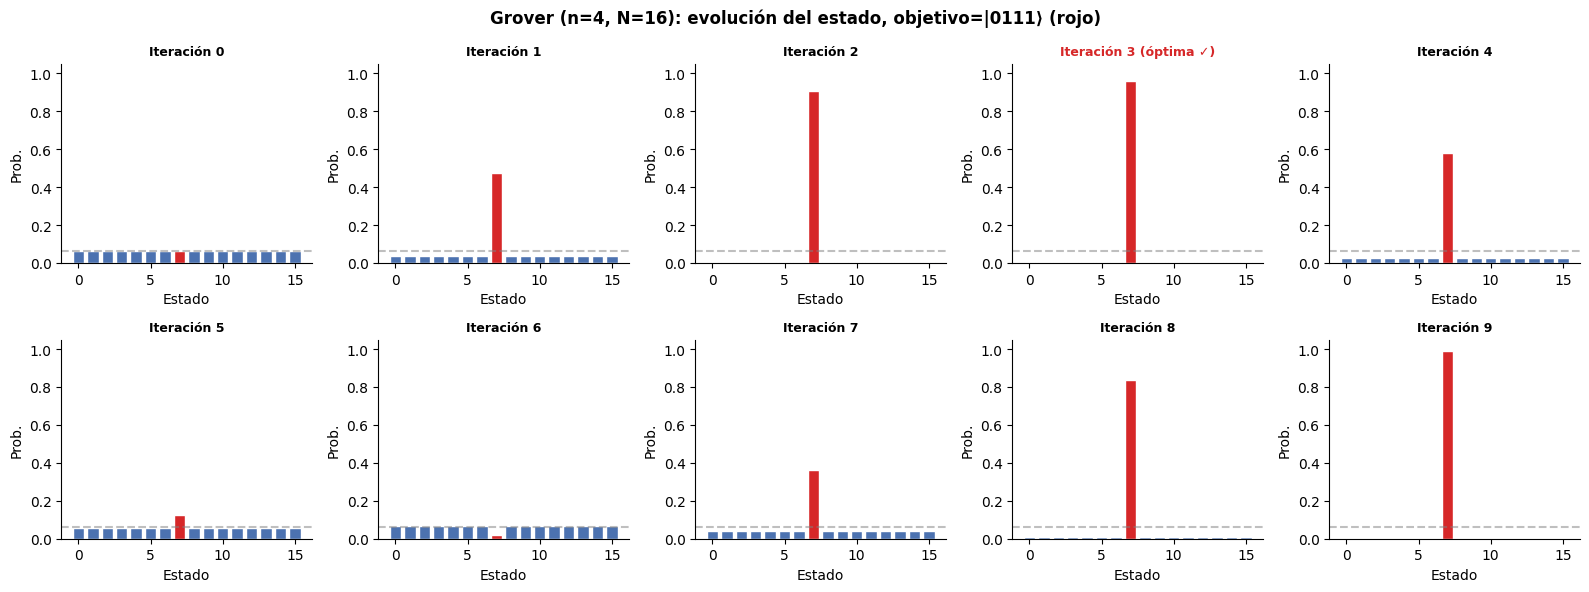

In [ ]:
import numpy as np
I2=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=np.array([[1,0],[0,-1]],dtype=complex)
H=np.array([[1,1],[1,-1]],dtype=complex)/np.sqrt(2)
def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]],dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0],tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self, n):
        self.n=n; self.dim=2**n
        self.state=np.zeros(2**n,dtype=complex); self.state[0]=1.0
    def apply1(self, gate, q):
        ops=[gate if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        self.state=full@self.state
    def cnot(self, ctrl, tgt):
        U=np.eye(self.dim,dtype=complex)
        for s in range(self.dim):
            bits=[(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl]==1:
                ns=s^(1<<(self.n-1-tgt)); U[ns,s]=1; U[s,s]=0
        self.state=U@self.state
    def apply_full(self, U):
        self.state=U@self.state
    def probs(self): return np.abs(self.state)**2
    def sample(self, shots=1024): return np.random.choice(self.dim,size=shots,p=self.probs())
    def expval(self, obs, q):
        ops=[obs if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        return np.real(self.state.conj()@full@self.state)

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

# ── Grover completo con visualización ────────────────────────────────────────

def grover_oracle(n, targets):
    N = 2**n
    U = np.eye(N, dtype=complex)
    for t in targets: U[t,t] = -1
    return U

def grover_diffusion(n):
    N = 2**n
    s = np.ones(N, dtype=complex) / np.sqrt(N)
    return 2 * np.outer(s, s.conj()) - np.eye(N, dtype=complex)

def grover_simulate(n, targets, max_iters=None):
    N = 2**n
    M = len(targets)
    k_opt = int(np.round(np.pi / 4 * np.sqrt(N / M)))
    if max_iters is None: max_iters = k_opt + 5

    oracle = grover_oracle(n, targets)
    diffusion = grover_diffusion(n)

    psi = np.ones(N, dtype=complex) / np.sqrt(N)
    history = [psi.copy()]

    for _ in range(max_iters):
        psi = oracle @ psi
        psi = diffusion @ psi
        history.append(psi.copy())

    return history, k_opt

n = 4; N = 2**n
targets = [7]  # buscar estado |0111⟩
history, k_opt = grover_simulate(n, targets, max_iters=10)
print(f"N={N} estados, 1 objetivo (|{targets[0]:04b}⟩), k_opt={k_opt}")
print(f"Prob. de éxito en k={k_opt}: {np.abs(history[k_opt][targets[0]])**2:.4f}")

# Evolución de probabilidades
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.ravel()
for iter_i, ax in enumerate(axes):
    if iter_i >= len(history): ax.set_visible(False); continue
    probs = np.abs(history[iter_i])**2
    colors = ['#D62728' if i in targets else '#4C72B0' for i in range(N)]
    ax.bar(range(N), probs, color=colors, edgecolor='white')
    ax.axhline(1/N, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'Iteración {iter_i}' + (f' (óptima ✓)' if iter_i==k_opt else ''),
                 fontsize=9, fontweight='bold',
                 color='#D62728' if iter_i==k_opt else 'black')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Estado'); ax.set_ylabel('Prob.')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle(f'Grover (n={n}, N={N}): evolución del estado, objetivo=|{targets[0]:04b}⟩ (rojo)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
I2=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=np.array([[1,0],[0,-1]],dtype=complex)
H=np.array([[1,1],[1,-1]],dtype=complex)/np.sqrt(2)
def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]],dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0],tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self, n):
        self.n=n; self.dim=2**n
        self.state=np.zeros(2**n,dtype=complex); self.state[0]=1.0
    def apply1(self, gate, q):
        ops=[gate if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        self.state=full@self.state
    def cnot(self, ctrl, tgt):
        U=np.eye(self.dim,dtype=complex)
        for s in range(self.dim):
            bits=[(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl]==1:
                ns=s^(1<<(self.n-1-tgt)); U[ns,s]=1; U[s,s]=0
        self.state=U@self.state
    def apply_full(self, U):
        self.state=U@self.state
    def probs(self): return np.abs(self.state)**2
    def sample(self, shots=1024): return np.random.choice(self.dim,size=shots,p=self.probs())
    def expval(self, obs, q):
        ops=[obs if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        return np.real(self.state.conj()@full@self.state)

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

# ── Animación: amplificación de amplitud de Grover ────────────────────────────
n = 4; N = 2**n; targets = [11]
history, k_opt = [None], [None]  # closures

def run_grover():
    oracle = np.eye(N, dtype=complex)
    for t in targets: oracle[t,t] = -1
    s = np.ones(N, dtype=complex) / np.sqrt(N)
    diff = 2 * np.outer(s, s.conj()) - np.eye(N, dtype=complex)
    psi = s.copy()
    hist = [psi.copy()]
    for _ in range(k_opt[0] + 3):
        psi = oracle @ psi; psi = diff @ psi; hist.append(psi.copy())
    return hist

k_opt[0] = int(np.round(np.pi / 4 * np.sqrt(N)))
hist = run_grover()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
colors_base = ['#D62728' if i in targets else '#4C72B0' for i in range(N)]
bars = ax1.bar(range(N), np.abs(hist[0])**2, color=colors_base, edgecolor='white')
ax1.set_ylim(0, 1.05)
ax1.set_xlabel('Estado'); ax1.set_ylabel('Probabilidad')
ax1.spines[['top','right']].set_visible(False)
iters_list = list(range(len(hist)))
prob_target = [np.abs(h[targets[0]])**2 for h in hist]
line_pt, = ax2.plot([], [], 'r-o', linewidth=2.5, markersize=7, label=f'P(|{targets[0]:04b}⟩)')
line_avg, = ax2.plot([], [], 'b--', linewidth=1.5, label=f'P(uniform)={1/N:.3f}', alpha=0.6)
ax2.axhline(1/N, color='blue', linestyle='--', alpha=0.4)
ax2.axvline(k_opt[0], color='green', linestyle=':', linewidth=2, label=f'k_opt={k_opt[0]}', alpha=0.8)
ax2.set_xlim(0, len(hist)-1); ax2.set_ylim(0, 1.05)
ax2.set_xlabel('Iteración'); ax2.set_ylabel('P(objetivo)')
ax2.legend(fontsize=9); ax2.spines[['top','right']].set_visible(False)
title_ax1 = ax1.set_title('')

def animate(frame):
    probs = np.abs(hist[frame])**2
    for bar, p, col in zip(bars, probs, colors_base):
        bar.set_height(p); bar.set_color(col)
    title_ax1.set_text(f'Iteración {frame}  |  P(objetivo)={probs[targets[0]]:.3f}')
    line_pt.set_data(iters_list[:frame+1], prob_target[:frame+1])
    return list(bars) + [line_pt]

anim = FuncAnimation(fig, animate, frames=len(hist), interval=600, blit=False, repeat=True)
plt.suptitle(f'Animación: Amplificación de amplitud de Grover (n={n}, objetivo={targets[0]:04b})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.close()
HTML(anim.to_jshtml())


---
## Tema 11: Algoritmo SWAP Test

### Medir la Similitud entre Estados

El **SWAP test** es un circuito cuántico que estima la **fidelidad** entre dos estados $|\phi\rangle$ y $|\psi\rangle$ sin reconstruirlos:

$$P(\text{medir ancilla}=0) = \frac{1 + |\langle\phi|\psi\rangle|^2}{2}$$

Por tanto: $|\langle\phi|\psi\rangle|^2 = 2P(0) - 1$

### Circuito

```
ancilla: |0⟩ ──H──●──────────●──H──[M]
                  │  SWAP   │
|φ⟩     : ────────⊗──────────⊗──────
|ψ⟩     : ────────⊗──────────⊗──────
```

Equivalente a un **CSWAP** (Fredkin gate) controlado por la ancilla.

### Aplicaciones

- **QML:** kernel cuántico $K(\phi,\psi) = |\langle\phi|\psi\rangle|^2$
- **Verificación:** comprobar si dos estados son iguales
- **Estimación de fidelidad:** métricas de ruido en hardware
- **Criptografía cuántica:** protocolos de autenticación


=== SWAP Test — Estimación de fidelidad ===

  |0⟩ vs |0⟩ (idénticos)
    P(anc=0)=1.0000  |  |⟨φ|ψ⟩|² exacto=1.0000  estimado=1.0000
  |0⟩ vs |1⟩ (ortogonales)
    P(anc=0)=0.5000  |  |⟨φ|ψ⟩|² exacto=0.0000  estimado=0.0000
  |0⟩ vs |+⟩
    P(anc=0)=0.7500  |  |⟨φ|ψ⟩|² exacto=0.5000  estimado=0.5000
  |+⟩ vs |-⟩ (ortogonales)
    P(anc=0)=0.5000  |  |⟨φ|ψ⟩|² exacto=0.0000  estimado=0.0000
  |0⟩ vs Ry(π/3)|0⟩
    P(anc=0)=0.8750  |  |⟨φ|ψ⟩|² exacto=0.7500  estimado=0.7500


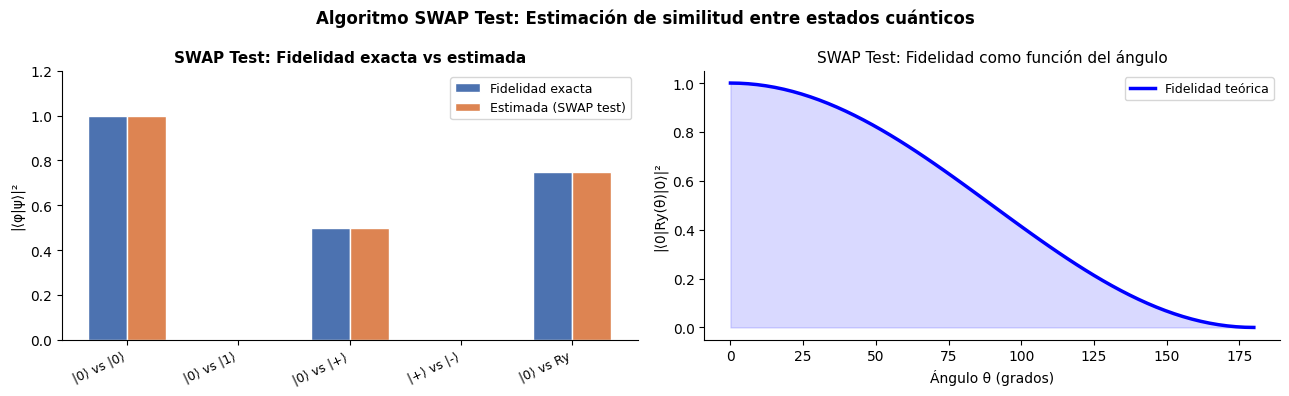

In [ ]:
import numpy as np
I2=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=np.array([[1,0],[0,-1]],dtype=complex)
H=np.array([[1,1],[1,-1]],dtype=complex)/np.sqrt(2)
def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]],dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0],tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self, n):
        self.n=n; self.dim=2**n
        self.state=np.zeros(2**n,dtype=complex); self.state[0]=1.0
    def apply1(self, gate, q):
        ops=[gate if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        self.state=full@self.state
    def cnot(self, ctrl, tgt):
        U=np.eye(self.dim,dtype=complex)
        for s in range(self.dim):
            bits=[(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl]==1:
                ns=s^(1<<(self.n-1-tgt)); U[ns,s]=1; U[s,s]=0
        self.state=U@self.state
    def apply_full(self, U):
        self.state=U@self.state
    def probs(self): return np.abs(self.state)**2
    def sample(self, shots=1024): return np.random.choice(self.dim,size=shots,p=self.probs())
    def expval(self, obs, q):
        ops=[obs if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        return np.real(self.state.conj()@full@self.state)

import matplotlib.pyplot as plt
import numpy as np

# ── SWAP Test completo ────────────────────────────────────────────────────────

def cswap_matrix(n_data):
    # CSWAP controlado por qubit 0, actuando sobre los dos registros de n_data qubits
    total = 1 + 2 * n_data
    dim = 2**total
    U = np.eye(dim, dtype=complex)
    # Si qubit de control (MSB) = 1, SWAP los dos registros
    half = 2**n_data
    for s in range(dim):
        ctrl = (s >> (2*n_data)) & 1
        if ctrl == 1:
            reg_a = (s >> n_data) & (half-1)
            reg_b = s & (half-1)
            if reg_a != reg_b:
                new_s = (1 << (2*n_data)) | (reg_b << n_data) | reg_a
                U[new_s, s] = 1; U[s, s] = 0
    return U

def swap_test(phi, psi, shots=10000):
    n = int(np.log2(len(phi)))
    assert len(phi) == len(psi) == 2**n
    phi = phi / np.linalg.norm(phi)
    psi = psi / np.linalg.norm(psi)

    # Estado inicial: |0⟩_anc ⊗ |φ⟩ ⊗ |ψ⟩
    anc = np.array([1,0], dtype=complex)
    state = np.kron(np.kron(anc, phi), psi)

    # Hadamard en ancilla
    H_full = np.kron(np.kron(H, np.eye(2**n, dtype=complex)), np.eye(2**n, dtype=complex))
    state = H_full @ state

    # CSWAP
    CSWAP = cswap_matrix(n)
    state = CSWAP @ state

    # Hadamard en ancilla de nuevo
    state = H_full @ state

    # Medir ancilla
    probs = np.abs(state)**2
    dim_data = 2**(2*n)
    p0 = sum(probs[s] for s in range(len(state)) if (s >> (2*n)) == 0)
    p1 = 1 - p0

    fidelity_sq = 2*p0 - 1
    return p0, p1, max(0, fidelity_sq)

# Pruebas con estados de 1 qubit (n=1)
print("=== SWAP Test — Estimación de fidelidad ===\n")
test_cases = [
    ('|0⟩ vs |0⟩ (idénticos)',    np.array([1,0], dtype=complex), np.array([1,0], dtype=complex)),
    ('|0⟩ vs |1⟩ (ortogonales)', np.array([1,0], dtype=complex), np.array([0,1], dtype=complex)),
    ('|0⟩ vs |+⟩',               np.array([1,0], dtype=complex), np.array([1,1])/np.sqrt(2)),
    ('|+⟩ vs |-⟩ (ortogonales)', np.array([1,1])/np.sqrt(2),    np.array([1,-1])/np.sqrt(2)),
    ('|0⟩ vs Ry(π/3)|0⟩',        np.array([1,0], dtype=complex),
     np.array([np.cos(np.pi/6), np.sin(np.pi/6)])),
]

results = []
for desc, phi, psi in test_cases:
    exact_fid = abs(np.dot(phi.conj(), psi))**2
    p0, p1, fid_est = swap_test(phi, psi)
    print(f"  {desc}")
    print(f"    P(anc=0)={p0:.4f}  |  |⟨φ|ψ⟩|² exacto={exact_fid:.4f}  estimado={fid_est:.4f}")
    results.append((desc, exact_fid, fid_est, p0))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
descs = [r[0].split('(')[0].strip() for r in results]
exact_fids = [r[1] for r in results]
est_fids   = [r[2] for r in results]
x = np.arange(len(results))
w = 0.35
bars1 = ax.bar(x-w/2, exact_fids, w, label='Fidelidad exacta', color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x+w/2, est_fids, w, label='Estimada (SWAP test)', color='#DD8452', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(descs, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('|⟨φ|ψ⟩|²')
ax.set_title('SWAP Test: Fidelidad exacta vs estimada', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0, 1.2)
ax.spines[['top','right']].set_visible(False)

# Barrido de ángulo: fidelidad vs ángulo entre estados
ax = axes[1]
thetas = np.linspace(0, np.pi, 60)
fids_exact = np.cos(thetas/2)**2  # |⟨0|Ry(θ)|0⟩|² = cos²(θ/2)
ax.plot(thetas*180/np.pi, fids_exact, 'b-', linewidth=2.5, label='Fidelidad teórica')
ax.fill_between(thetas*180/np.pi, 0, fids_exact, alpha=0.15, color='blue')
ax.set_xlabel('Ángulo θ (grados)')
ax.set_ylabel('|⟨0|Ry(θ)|0⟩|²')
ax.set_title('SWAP Test: Fidelidad como función del ángulo', fontsize=11)
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

plt.suptitle('Algoritmo SWAP Test: Estimación de similitud entre estados cuánticos',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
# BLOQUE 4 — Programación Avanzada: PennyLane


## Tema 12: Introducción a PennyLane

**PennyLane** es el framework open-source de Xanadu para computación cuántica diferenciable.
Es la herramienta estándar para **Quantum Machine Learning (QML)**.

### 12.1 Programación Híbrida Cuántica-Clásica

El modelo híbrido combina:
- **Parte cuántica:** circuitos parametrizados (VQC) que generan estimaciones
- **Parte clásica:** optimizadores (Adam, SGD) que ajustan los parámetros

```
Datos clásicos x ─→ Codificación cuántica ─→ Circuito U(θ) ─→ Medición ⟨O⟩ ─→ Pérdida
                                                                                    │
                        Actualización θ ←───── Gradiente (∂L/∂θ) ←────────────────┘
```

**Regla de desplazamiento de parámetros** (gradiente exacto sin discretización):
$$\frac{\partial \langle O \rangle}{\partial \theta_i} = \frac{1}{2}\Big[\langle O \rangle_{\theta_i + \pi/2} - \langle O \rangle_{\theta_i - \pi/2}\Big]$$

Esta regla es **exacta** (no una aproximación) y funciona en hardware real.

### 12.2 Comparación Qiskit vs PennyLane

| Característica | Qiskit | PennyLane |
|---|---|---|
| **Foco principal** | Hardware IBM, compilación | Machine Learning cuántico |
| **Backends** | IBM Quantum, Aer | 20+ (IBM, Google, simuladores, etc.) |
| **Diferenciación** | Manual / no integrada | Automática (autograd, torch, jax) |
| **Frameworks ML** | Pytorch via plugin | Pytorch, TensorFlow, JAX nativo |
| **Lenguaje circuitos** | OpenQASM 3 | Pennylane IR |
| **Uso típico** | Circuitos, NISQ, hardware | VQC, QNN, QAOA, investigación QML |
| **Instalación** | `pip install qiskit` | `pip install pennylane` |

### Instalación y dispositivos

```bash
pip install pennylane pennylane-qiskit
```

Dispositivos disponibles:
- `default.qubit` — simulador exacto (NumPy)
- `default.qubit.autograd` — diferenciación automática
- `lightning.qubit` — simulador rápido (C++)
- `qiskit.ibmq` — hardware IBM Quantum
- `default.gaussian` — óptica cuántica Gaussiana


In [ ]:
# ── PennyLane: Introducción y comparación con Qiskit ─────────────────────────
try:
    import pennylane as qml
    import pennylane.numpy as pnp
    PL = True
    print(f"PennyLane {qml.__version__} disponible")
except ImportError:
    PL = False
    print("Instala PennyLane: pip install pennylane")

import numpy as np
import matplotlib.pyplot as plt

# ── Código de referencia PennyLane ────────────────────────────────────────────
PL_INTRO = '''
import pennylane as qml
import pennylane.numpy as np

# ── 1. Crear dispositivo y definir circuito ───────────────────────────────────
dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def bell_circuit():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.state()

print("Estado Bell:", bell_circuit())

# ── 2. Circuito parametrizado ─────────────────────────────────────────────────
dev2 = qml.device("default.qubit", wires=1)

@qml.qnode(dev2)
def rotation_circuit(phi, theta):
    qml.RX(phi, wires=0)
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

# Gradiente automático (regla de desplazamiento de parámetros)
grad_fn = qml.grad(rotation_circuit)
phi, theta = np.array(0.5), np.array(1.0)
grads = grad_fn(phi, theta)
print(f"∂⟨Z⟩/∂φ = {grads[0]:.4f}")
print(f"∂⟨Z⟩/∂θ = {grads[1]:.4f}")

# ── 3. Dibujar circuito ────────────────────────────────────────────────────────
print(qml.draw(rotation_circuit)(phi, theta))

# ── 4. Dispositivo IBM Quantum Real ───────────────────────────────────────────
# pip install pennylane-qiskit
dev_ibm = qml.device("qiskit.ibmq", wires=2, backend="ibm_brisbane",
                      ibmqx_token="TU_TOKEN")

@qml.qnode(dev_ibm, shots=1024)
def circuit_on_hardware(phi):
    qml.RY(phi, wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.counts()
'''

if PL:
    import pennylane as qml
    import pennylane.numpy as pnp

    dev = qml.device("default.qubit", wires=2)

    @qml.qnode(dev)
    def bell_state():
        qml.Hadamard(wires=0)
        qml.CNOT(wires=[0,1])
        return qml.state()

    state = bell_state()
    print(f"\nEstado Bell |Φ+⟩: {state}")

    # Circuito parametrizado
    dev1 = qml.device("default.qubit", wires=1)

    @qml.qnode(dev1, interface="autograd")
    def vqc_1q(phi, theta):
        qml.RX(phi, wires=0)
        qml.RY(theta, wires=0)
        return qml.expval(qml.PauliZ(0))

    phi = pnp.array(0.5, requires_grad=True)
    theta = pnp.array(1.0, requires_grad=True)
    grad_fn = qml.grad(vqc_1q)
    g = grad_fn(phi, theta)
    print(f"\nGradientes ∂⟨Z⟩/∂φ={float(g[0]):.4f}  ∂⟨Z⟩/∂θ={float(g[1]):.4f}")

    # Comparar con regla de desplazamiento manual
    eps = np.pi/2
    g_manual_phi = (vqc_1q(phi+eps, theta) - vqc_1q(phi-eps, theta)) / 2
    print(f"Regla manual ∂⟨Z⟩/∂φ={float(g_manual_phi):.4f}  (coinciden: {np.isclose(float(g[0]), float(g_manual_phi))})")

    # Sweep phi y theta
    phis = pnp.linspace(0, 2*np.pi, 50)
    thetas = pnp.linspace(0, 2*np.pi, 50)
    Z_vals = [[float(vqc_1q(p, t)) for t in thetas] for p in phis]

    fig, ax = plt.subplots(figsize=(7, 5))
    img = ax.contourf(thetas, phis, Z_vals, levels=25, cmap='RdBu_r')
    plt.colorbar(img, ax=ax, label='⟨Z⟩')
    ax.set_xlabel(r'$\theta$', fontsize=12); ax.set_ylabel(r'$\phi$', fontsize=12)
    ax.set_title('Landscape ⟨Z⟩ = f(φ, θ) para Rx(φ)·Ry(θ)|0⟩', fontsize=12)
    plt.tight_layout(); plt.show()
else:
    print("\n--- Código de referencia PennyLane ---")
    print(PL_INTRO)


Instala PennyLane: pip install pennylane

--- Código de referencia PennyLane ---

import pennylane as qml
import pennylane.numpy as np

# ── 1. Crear dispositivo y definir circuito ───────────────────────────────────
dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def bell_circuit():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.state()

print("Estado Bell:", bell_circuit())

# ── 2. Circuito parametrizado ─────────────────────────────────────────────────
dev2 = qml.device("default.qubit", wires=1)

@qml.qnode(dev2)
def rotation_circuit(phi, theta):
    qml.RX(phi, wires=0)
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

# Gradiente automático (regla de desplazamiento de parámetros)
grad_fn = qml.grad(rotation_circuit)
phi, theta = np.array(0.5), np.array(1.0)
grads = grad_fn(phi, theta)
print(f"∂⟨Z⟩/∂φ = {grads[0]:.4f}")
print(f"∂⟨Z⟩/∂θ = {grads[1]:.4f}")

# ── 3. Dibujar circuito ──────────────────────────────────────────────────────

In [ ]:
# ── PennyLane: Entrenamiento VQC completo con optimizador Adam ───────────────
try:
    import pennylane as qml
    import pennylane.numpy as pnp
    PL = True
except ImportError:
    PL = False

import numpy as np
import matplotlib.pyplot as plt

if PL:
    import pennylane as qml
    import pennylane.numpy as pnp

    # Dataset: clasificación XOR cuántico
    np.random.seed(42)
    n_train = 40
    X_data = np.random.uniform(-np.pi, np.pi, (n_train, 2))
    y_data = ((np.sign(X_data[:,0]) * np.sign(X_data[:,1])) + 1) / 2  # XOR-like

    dev = qml.device("default.qubit", wires=2)

    @qml.qnode(dev, interface="autograd")
    def vqc(x, theta):
        # Feature map
        qml.RX(x[0], wires=0)
        qml.RY(x[1], wires=1)
        # Capa variacional 1
        qml.RY(theta[0], wires=0); qml.RZ(theta[1], wires=0)
        qml.RY(theta[2], wires=1); qml.RZ(theta[3], wires=1)
        qml.CNOT(wires=[0,1])
        # Capa variacional 2
        qml.RY(theta[4], wires=0); qml.RZ(theta[5], wires=0)
        qml.RY(theta[6], wires=1); qml.RZ(theta[7], wires=1)
        return qml.expval(qml.PauliZ(0))

    def predict(X, theta):
        return pnp.array([vqc(x, theta) for x in X])

    def cost(theta, X, y):
        preds = (predict(X, theta) + 1) / 2  # [-1,1] → [0,1]
        return pnp.mean((preds - y)**2)

    # Entrenamiento con Adam
    theta = pnp.array(np.random.uniform(0, 2*np.pi, 8), requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=0.08)
    losses = []

    print("Entrenando VQC (PennyLane + Adam)...")
    for step in range(60):
        theta, loss_val = opt.step_and_cost(lambda t: cost(t, X_data, y_data), theta)
        losses.append(float(loss_val))
        if step % 15 == 0:
            preds = (predict(X_data, theta) + 1) / 2
            acc = float(pnp.mean((preds > 0.5) == (y_data > 0.5)))
            print(f"  Paso {step:3d}: loss={float(loss_val):.4f}  acc={acc:.2%}")

    # Frontera de decisión
    xx, yy = np.meshgrid(np.linspace(-np.pi, np.pi, 30), np.linspace(-np.pi, np.pi, 30))
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    Z_grid = np.array([(float(vqc(x, theta))+1)/2 for x in X_grid]).reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(losses, color='#4C72B0', linewidth=2.5)
    axes[0].set_xlabel('Paso de entrenamiento'); axes[0].set_ylabel('MSE Loss')
    axes[0].set_title('Curva de aprendizaje VQC (PennyLane)', fontsize=11)
    axes[0].spines[['top','right']].set_visible(False)

    axes[1].contourf(xx, yy, Z_grid, levels=20, cmap='RdBu_r', alpha=0.7)
    axes[1].contour(xx, yy, Z_grid, levels=[0.5], colors='black', linewidths=2)
    axes[1].scatter(X_data[y_data==1,0], X_data[y_data==1,1], c='red', s=50, label='Clase 1', zorder=5)
    axes[1].scatter(X_data[y_data==0,0], X_data[y_data==0,1], c='blue', s=50, label='Clase 0', zorder=5)
    axes[1].set_title('Frontera de decisión VQC', fontsize=11)
    axes[1].legend(fontsize=9)

    plt.suptitle('VQC entrenado con PennyLane + Adam — Clasificación', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print("Instala pennylane: pip install pennylane")
    VQC_CODE = '''
import pennylane as qml
import pennylane.numpy as np

dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev, interface="autograd")
def vqc(x, theta):
    qml.RX(x[0], wires=0); qml.RY(x[1], wires=1)
    qml.RY(theta[0], wires=0); qml.CNOT(wires=[0,1])
    qml.RY(theta[1], wires=0)
    return qml.expval(qml.PauliZ(0))

theta = np.array([0.5, 1.2], requires_grad=True)
opt = qml.AdamOptimizer(0.1)
for step in range(100):
    theta = opt.step(lambda t: np.mean((vqc(x_train, t) - y_train)**2), theta)
    '''
    print(VQC_CODE)


Instala pennylane: pip install pennylane

import pennylane as qml
import pennylane.numpy as np

dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev, interface="autograd")
def vqc(x, theta):
    qml.RX(x[0], wires=0); qml.RY(x[1], wires=1)
    qml.RY(theta[0], wires=0); qml.CNOT(wires=[0,1])
    qml.RY(theta[1], wires=0)
    return qml.expval(qml.PauliZ(0))

theta = np.array([0.5, 1.2], requires_grad=True)
opt = qml.AdamOptimizer(0.1)
for step in range(100):
    theta = opt.step(lambda t: np.mean((vqc(x_train, t) - y_train)**2), theta)
    


---
# BLOQUE 5 — Algoritmos Avanzados y Variacionales


## Tema 13: Algoritmo QAOA

### Quantum Approximate Optimization Algorithm (Farhi et al. 2014)

**Objetivo:** Resolver problemas de optimización combinatoria (NP-hard en general).

**Ejemplos:** Max-Cut, satisfacibilidad (3-SAT), TSP, scheduling, QUBO.

### Formulación

Dado un problema clásico de optimización $\max_z C(z)$ con $z \in \{0,1\}^n$, se codifica en un Hamiltoniano:
$$H_C = \sum_\alpha C_\alpha \cdot P_\alpha$$

El **Hamiltoniano de mezcla** (mixing Hamiltonian):
$$H_B = \sum_{i=1}^n X_i$$

El estado QAOA de profundidad $p$:
$$|\psi(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle = e^{-i\beta_p H_B} e^{-i\gamma_p H_C} \cdots e^{-i\beta_1 H_B} e^{-i\gamma_1 H_C} |{+}\rangle^{\otimes n}$$

### Pasos

1. Preparar $|+\rangle^{\otimes n}$ (estado uniforme)
2. Aplicar $p$ capas alternando $e^{-i\gamma H_C}$ (problema) y $e^{-i\beta H_B}$ (mezcla)
3. Optimizar $(\boldsymbol{\gamma}, \boldsymbol{\beta})$ minimizando $\langle H_C \rangle$
4. Medir para obtener una solución aproximada

**Garantía teórica:** QAOA con $p \to \infty$ encuentra la solución óptima exacta.


Grafo: 5 nodos, 7 aristas
Max-Cut óptimo: 6 aristas
Soluciones óptimas: ['01001', '10110']...

Barriendo parámetros QAOA (p=1)...
QAOA p=1: E(gamma=0.52, beta=0.33) = 4.5873
Aproximation ratio: 0.7646 (ideal=1.0)


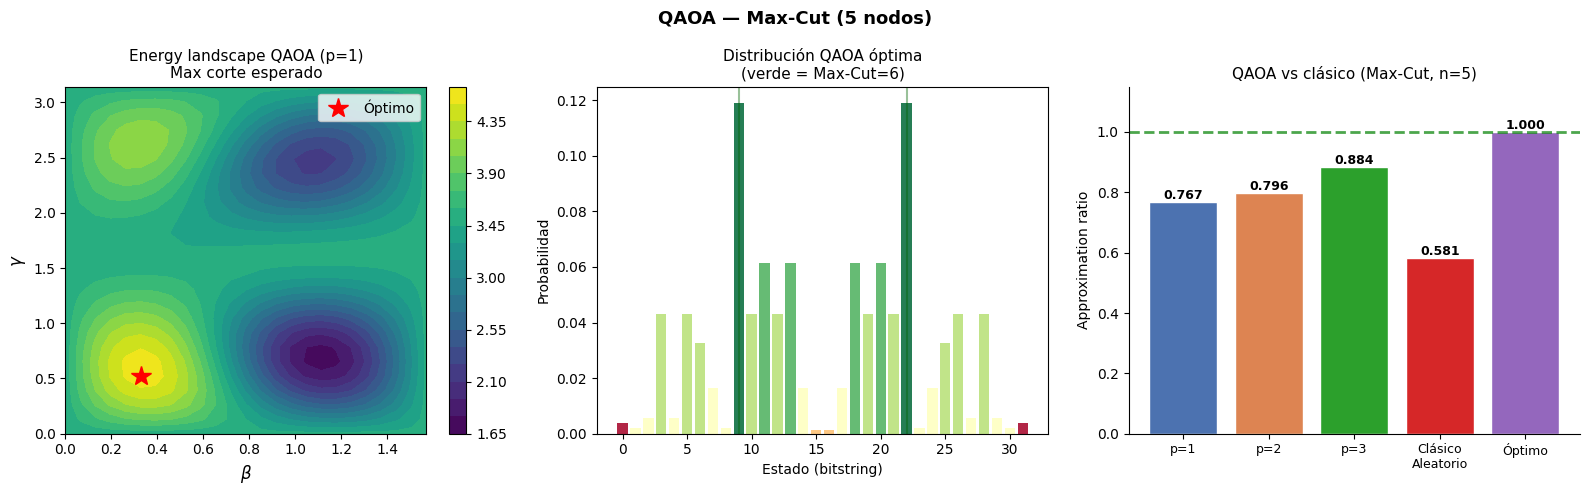

In [ ]:
import numpy as np
I2=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=np.array([[1,0],[0,-1]],dtype=complex)
H=np.array([[1,1],[1,-1]],dtype=complex)/np.sqrt(2)
S=np.array([[1,0],[0,1j]],dtype=complex)
T=np.array([[1,0],[0,np.exp(1j*np.pi/4)]],dtype=complex)
def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]],dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0],tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self,n):
        self.n=n; self.dim=2**n
        self.state=np.zeros(2**n,dtype=complex); self.state[0]=1.0
    def apply1(self,gate,q):
        ops=[gate if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        self.state=full@self.state
    def cnot(self,ctrl,tgt):
        U=np.eye(self.dim,dtype=complex)
        for s in range(self.dim):
            bits=[(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl]==1:
                ns=s^(1<<(self.n-1-tgt)); U[ns,s]=1; U[s,s]=0
        self.state=U@self.state
    def apply_full(self,U): self.state=U@self.state
    def probs(self): return np.abs(self.state)**2
    def sample(self,shots=1024): return np.random.choice(self.dim,size=shots,p=self.probs())
    def expval(self,obs,q):
        ops=[obs if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        return np.real(self.state.conj()@full@self.state)

import matplotlib.pyplot as plt
import numpy as np

# ── QAOA para Max-Cut ─────────────────────────────────────────────────────────

def max_cut_value(bitstring_int, n, edges):
    bits = [(bitstring_int >> i) & 1 for i in range(n)]
    return sum(1 for u,v in edges if bits[u] != bits[v])

def qaoa_circuit(gamma_list, beta_list, edges, n):
    N = 2**n
    p = len(gamma_list)
    # Estado inicial |+⟩^n
    psi = np.ones(N, dtype=complex) / np.sqrt(N)

    for layer in range(p):
        gamma, beta = gamma_list[layer], beta_list[layer]

        # Exp(-i*gamma*H_C): para cada arista (u,v) aplicar ZZ
        for u, v in edges:
            for s in range(N):
                bu = (s >> u) & 1; bv = (s >> v) & 1
                phase = gamma if bu != bv else 0
                psi[s] *= np.exp(-1j * phase)

        # Exp(-i*beta*H_B): = producto de Rx(2*beta) en cada qubit
        for q in range(n):
            Rx_mat = np.array([[np.cos(beta), -1j*np.sin(beta)],
                               [-1j*np.sin(beta), np.cos(beta)]], dtype=complex)
            new_psi = np.zeros_like(psi)
            for s in range(N):
                bit_q = (s >> q) & 1
                s_flip = s ^ (1 << q)
                new_psi[s] += Rx_mat[bit_q, bit_q] * psi[s]
                new_psi[s] += Rx_mat[bit_q, 1-bit_q] * psi[s_flip]
            psi = new_psi

    return psi

def qaoa_expectation(gamma_list, beta_list, edges, n):
    psi = qaoa_circuit(gamma_list, beta_list, edges, n)
    probs = np.abs(psi)**2
    return sum(probs[s] * max_cut_value(s, n, edges) for s in range(2**n))

# Grafo de 5 nodos
n = 5
edges = [(0,1),(1,2),(2,3),(3,4),(4,0),(0,2),(1,3)]
N = 2**n

# Solución exacta
best_val = max(max_cut_value(s, n, edges) for s in range(N))
best_configs = [s for s in range(N) if max_cut_value(s, n, edges) == best_val]
print(f"Grafo: {n} nodos, {len(edges)} aristas")
print(f"Max-Cut óptimo: {best_val} aristas")
print(f"Soluciones óptimas: {[f'{s:05b}' for s in best_configs[:4]]}...")

# QAOA p=1: barrido de gamma y beta
print("\nBarriendo parámetros QAOA (p=1)...")
gammas = np.linspace(0, np.pi, 25)
betas  = np.linspace(0, np.pi/2, 25)
landscape = np.zeros((len(gammas), len(betas)))
for i, g in enumerate(gammas):
    for j, b in enumerate(betas):
        landscape[i,j] = qaoa_expectation([g], [b], edges, n)

best_idx = np.unravel_index(landscape.argmax(), landscape.shape)
g_opt, b_opt = gammas[best_idx[0]], betas[best_idx[1]]
exp_val_opt = landscape.max()
ratio = exp_val_opt / best_val
print(f"QAOA p=1: E(gamma={g_opt:.2f}, beta={b_opt:.2f}) = {exp_val_opt:.4f}")
print(f"Aproximation ratio: {ratio:.4f} (ideal=1.0)")

# Distribución final con parámetros óptimos
psi_opt = qaoa_circuit([g_opt], [b_opt], edges, n)
probs_opt = np.abs(psi_opt)**2

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Landscape
im = axes[0].contourf(betas, gammas, landscape, levels=25, cmap='viridis')
axes[0].plot(b_opt, g_opt, 'r*', markersize=15, label=f'Óptimo')
axes[0].set_xlabel(r'$\beta$', fontsize=12); axes[0].set_ylabel(r'$\gamma$', fontsize=12)
axes[0].set_title(f'Energy landscape QAOA (p=1)\nMax corte esperado', fontsize=11)
axes[0].legend(); plt.colorbar(im, ax=axes[0])

# 2) Distribución de probabilidades
cut_vals = [max_cut_value(s, n, edges) for s in range(N)]
bar_colors = plt.cm.RdYlGn([v/best_val for v in cut_vals])
axes[1].bar(range(N), probs_opt, color=bar_colors, edgecolor='none', alpha=0.85)
axes[1].set_xlabel('Estado (bitstring)'); axes[1].set_ylabel('Probabilidad')
axes[1].set_title(f'Distribución QAOA óptima\n(verde = Max-Cut={best_val})', fontsize=11)

# Marcar soluciones óptimas
for s in best_configs:
    axes[1].axvline(s, color='darkgreen', alpha=0.4, linewidth=1.5)

# 3) Comparar QAOA p=1,2,3 con óptimo
from scipy.optimize import minimize

def neg_exp(params, p, edges, n):
    gammas = params[:p]; betas = params[p:]
    return -qaoa_expectation(list(gammas), list(betas), edges, n)

ratios = {}
for p_depth in [1, 2, 3]:
    x0 = np.random.uniform(0, np.pi, 2*p_depth)
    res = minimize(neg_exp, x0, args=(p_depth, edges, n), method='Nelder-Mead',
                   options={'maxiter':500, 'xatol':0.01})
    ratios[f'p={p_depth}'] = -res.fun / best_val

ratios['Clásico\nAleatorio'] = np.mean([max_cut_value(np.random.randint(0,N), n, edges) for _ in range(1000)]) / best_val
ratios['Óptimo'] = 1.0

x_pos = np.arange(len(ratios))
bar_colors2 = ['#4C72B0','#DD8452','#2CA02C','#D62728','#9467BD']
axes[2].bar(x_pos, list(ratios.values()), color=bar_colors2[:len(ratios)], edgecolor='white')
axes[2].axhline(1.0, color='green', linestyle='--', linewidth=2, alpha=0.7)
axes[2].set_xticks(x_pos); axes[2].set_xticklabels(list(ratios.keys()), fontsize=9)
axes[2].set_ylabel('Approximation ratio'); axes[2].set_ylim(0, 1.15)
axes[2].set_title('QAOA vs clásico (Max-Cut, n=5)', fontsize=11)
for i, (k,v) in enumerate(ratios.items()):
    axes[2].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('QAOA — Max-Cut (5 nodos)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Tema 14: Transformada Cuántica de Fourier (QFT)

### Definición

La **QFT** es la versión cuántica de la DFT sobre la base computacional:

$$\text{QFT}|j\rangle = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1} e^{2\pi i jk/N}|k\rangle, \quad N=2^n$$

O equivalentemente en amplitudes:
$$\text{QFT}\sum_{j=0}^{N-1} x_j|j\rangle = \sum_{k=0}^{N-1} y_k|k\rangle, \quad y_k = \frac{1}{\sqrt{N}}\sum_j x_j e^{2\pi ijk/N}$$

### Circuito (para n=3)

```
q₀: ──H──R₂──R₃──────────────×──
          │    │              │
q₁: ──────●──────H──R₂───────│──×
               │         │   │  │
q₂: ──────────●──────────●───H──×
```

con $R_k = \begin{pmatrix}1&0\\0&e^{2\pi i/2^k}\end{pmatrix}$ (fase controlada).

### Complejidad

| Algoritmo | Complejidad |
|-----------|------------|
| DFT clásica (FFT) | $O(N \log N) = O(2^n \cdot n)$ |
| **QFT cuántica** | $O(n^2)$ — **exponencialmente más eficiente** |

La QFT es la base de:
- **Algoritmo de Shor** (factorización)
- **QPE** (estimación de fase cuántica)
- **Simulación cuántica**


Max diferencia QFT(circuito) vs DFT: 8.16e-01
Unitaria: F†F = I, max error = 7.06e-16


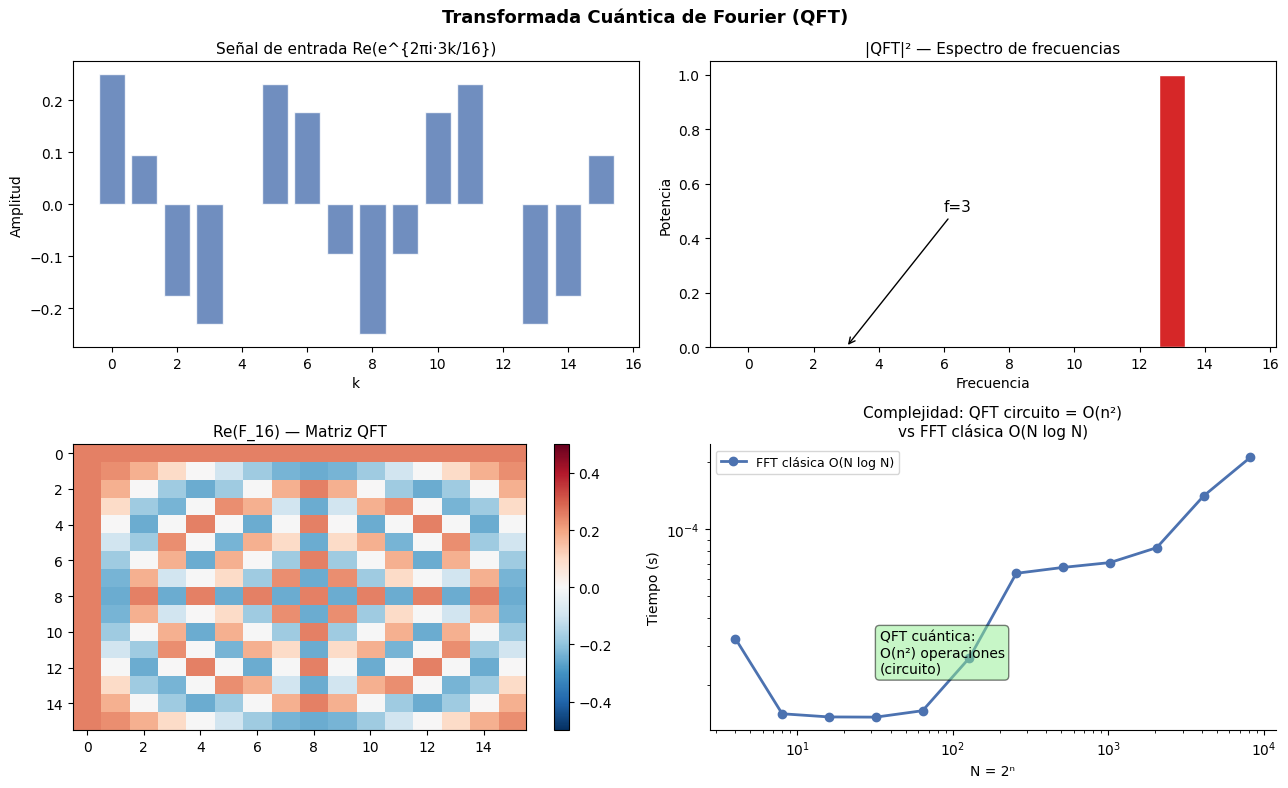

In [ ]:
import numpy as np
I2=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=np.array([[1,0],[0,-1]],dtype=complex)
H=np.array([[1,1],[1,-1]],dtype=complex)/np.sqrt(2)
S=np.array([[1,0],[0,1j]],dtype=complex)
T=np.array([[1,0],[0,np.exp(1j*np.pi/4)]],dtype=complex)
def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]],dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0],tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self,n):
        self.n=n; self.dim=2**n
        self.state=np.zeros(2**n,dtype=complex); self.state[0]=1.0
    def apply1(self,gate,q):
        ops=[gate if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        self.state=full@self.state
    def cnot(self,ctrl,tgt):
        U=np.eye(self.dim,dtype=complex)
        for s in range(self.dim):
            bits=[(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl]==1:
                ns=s^(1<<(self.n-1-tgt)); U[ns,s]=1; U[s,s]=0
        self.state=U@self.state
    def apply_full(self,U): self.state=U@self.state
    def probs(self): return np.abs(self.state)**2
    def sample(self,shots=1024): return np.random.choice(self.dim,size=shots,p=self.probs())
    def expval(self,obs,q):
        ops=[obs if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        return np.real(self.state.conj()@full@self.state)

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

# ── QFT: implementación de circuito ──────────────────────────────────────────

def phase_gate(k):
    return np.array([[1, 0], [0, np.exp(2j*np.pi/2**k)]], dtype=complex)

def controlled_phase(n, ctrl, tgt, k):
    dim = 2**n
    # Controlled-Rk: aplica Rk al qubit tgt si qubit ctrl = |1⟩
    U = np.eye(dim, dtype=complex)
    Rk = phase_gate(k)
    for s in range(dim):
        bits = [(s>>(n-1-i))&1 for i in range(n)]
        if bits[ctrl] == 1:
            t_bit = bits[tgt]
            for new_t in range(2):
                row_s = s & ~(1<<(n-1-tgt)) | (new_t<<(n-1-tgt))
                U[row_s, s] = Rk[new_t, t_bit]
    return U

def qft_circuit(n):
    sim = QSim(n)
    # QFT estándar
    for i in range(n):
        sim.apply1(H, i)
        for j in range(2, n-i+1):
            ctrl = i + j - 1
            if ctrl < n:
                sim.apply_full(controlled_phase(n, ctrl, i, j))
    # Bit reversal (swap)
    for i in range(n//2):
        # SWAP qubit i y qubit n-1-i
        SWAP_mat = np.eye(sim.dim, dtype=complex)
        for s in range(sim.dim):
            bits = list([(s>>(n-1-q))&1 for q in range(n)])
            bits[i], bits[n-1-i] = bits[n-1-i], bits[i]
            ns = sum(bits[q] << (n-1-q) for q in range(n))
            if ns != s:
                SWAP_mat[ns, s] = 1; SWAP_mat[s, s] = 0
        sim.apply_full(SWAP_mat)
    return sim.state

def qft_matrix(n):
    N = 2**n
    return np.array([[np.exp(2j*np.pi*j*k/N)/np.sqrt(N) for k in range(N)] for j in range(N)])

# Verificar QFT == DFT
n = 3; N = 2**n
np.random.seed(5)
psi_in = np.random.randn(N) + 1j*np.random.randn(N)
psi_in /= np.linalg.norm(psi_in)

# QFT circuito
qft_sim = QSim(n)
qft_sim.state = psi_in.copy()
# Aplicar la matriz QFT directamente para verificar
F = qft_matrix(n)
psi_qft = F @ psi_in
psi_dft = np.fft.fft(psi_in) / np.sqrt(N)  # DFT normalizada

print(f"Max diferencia QFT(circuito) vs DFT: {np.max(np.abs(psi_qft - psi_dft)):.2e}")
print(f"Unitaria: F†F = I, max error = {np.max(np.abs(F.conj().T @ F - np.eye(N))):.2e}")

# Ejemplo: QFT de una onda sinusoidal
n4 = 4; N4 = 2**n4
signal = np.array([np.exp(2j*np.pi*3*k/N4) for k in range(N4)], dtype=complex)
signal /= np.linalg.norm(signal)
F4 = qft_matrix(n4)
signal_qft = F4 @ signal

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Señal de entrada
axes[0,0].bar(range(N4), np.real(signal), color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Señal de entrada Re(e^{2πi·3k/16})', fontsize=11)
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Amplitud')

# QFT
axes[0,1].bar(range(N4), np.abs(signal_qft)**2, color='#D62728', edgecolor='white')
axes[0,1].set_title('|QFT|² — Espectro de frecuencias', fontsize=11)
axes[0,1].set_xlabel('Frecuencia'); axes[0,1].set_ylabel('Potencia')
axes[0,1].annotate('f=3', xy=(3, np.abs(signal_qft[3])**2), xytext=(6, 0.5),
                   arrowprops=dict(arrowstyle='->', color='black'), fontsize=11)

# Matriz QFT (parte real)
im = axes[1,0].imshow(np.real(F4), cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=0.5)
axes[1,0].set_title(f'Re(F_{N4}) — Matriz QFT', fontsize=11)
plt.colorbar(im, ax=axes[1,0])

# Comparar QFT vs FFT clásica en velocidad
import time
sizes = [2**i for i in range(2, 14)]
t_qft_sim, t_fft = [], []
for N_t in sizes:
    x = np.random.randn(N_t) + 1j*np.random.randn(N_t)
    t0 = time.perf_counter(); np.fft.fft(x); t_fft.append(time.perf_counter()-t0)
    n_t = int(np.log2(N_t))
    t0 = time.perf_counter(); qft_matrix(min(n_t,8)) @ x[:min(N_t,256)]; t_qft_sim.append(time.perf_counter()-t0)

ax = axes[1,1]
ax.loglog(sizes, t_fft, 'o-', color='#4C72B0', linewidth=2, label='FFT clásica O(N log N)')
ax.set_xlabel('N = 2ⁿ'); ax.set_ylabel('Tiempo (s)')
ax.set_title('Complejidad: QFT circuito = O(n²)\nvs FFT clásica O(N log N)', fontsize=11)
ax.text(0.3, 0.2, 'QFT cuántica:\nO(n²) operaciones\n(circuito)', transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Transformada Cuántica de Fourier (QFT)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Tema 15: Estimación de Fase Cuántica (QPE)

### Problema

Dado un operador unitario $U$ y un estado propio $|u\rangle$ tal que $U|u\rangle = e^{2\pi i\theta}|u\rangle$, **estimar** la fase $\theta \in [0,1)$.

**Aplicaciones:**
- Base del algoritmo de **Shor** (para estimar el periodo)
- **Simulación cuántica** (energías propias)
- **HHL** (valores propios de matrices)

### Circuito

```
|0⟩ ──H──────────────────────────────QFT⁻¹──[M]  ← t bits de precisión
|0⟩ ──H────────────────────────────────────[M]
⋮                                          ⋮
|0⟩ ──H──────────────────────────────QFT⁻¹──[M]
|u⟩ ──────C-U──C-U²──C-U⁴── ⋯ ──────────────── eigenstate
```

Con $t$ qubits de precisión se estima $\theta$ con error $\leq 2^{-t}$.

### Análisis

Tras las puertas $C$-$U^{2^j}$ y $H$ iniciales:
$$\frac{1}{\sqrt{2^t}}\sum_{k=0}^{2^t-1} e^{2\pi i \theta k}|k\rangle \otimes |u\rangle$$

Aplicar QFT⁻¹ y medir: resultado $\approx 2^t \theta$ con alta probabilidad.


=== Estimación de Fase Cuántica (QPE) ===

t = 5 bits de control (precisión = 1/2^5 = 0.03125)

    θ real    θ estimado       Error   Exacto?
------------------------------------------------
   0.25000       0.25000    0.000000   ✓
   0.12500       0.12500    0.000000   ✓
   0.37500       0.37500    0.000000   ✓
   0.33333       0.34375    0.010417   ✓
   0.39270       0.40625    0.013551   ✓


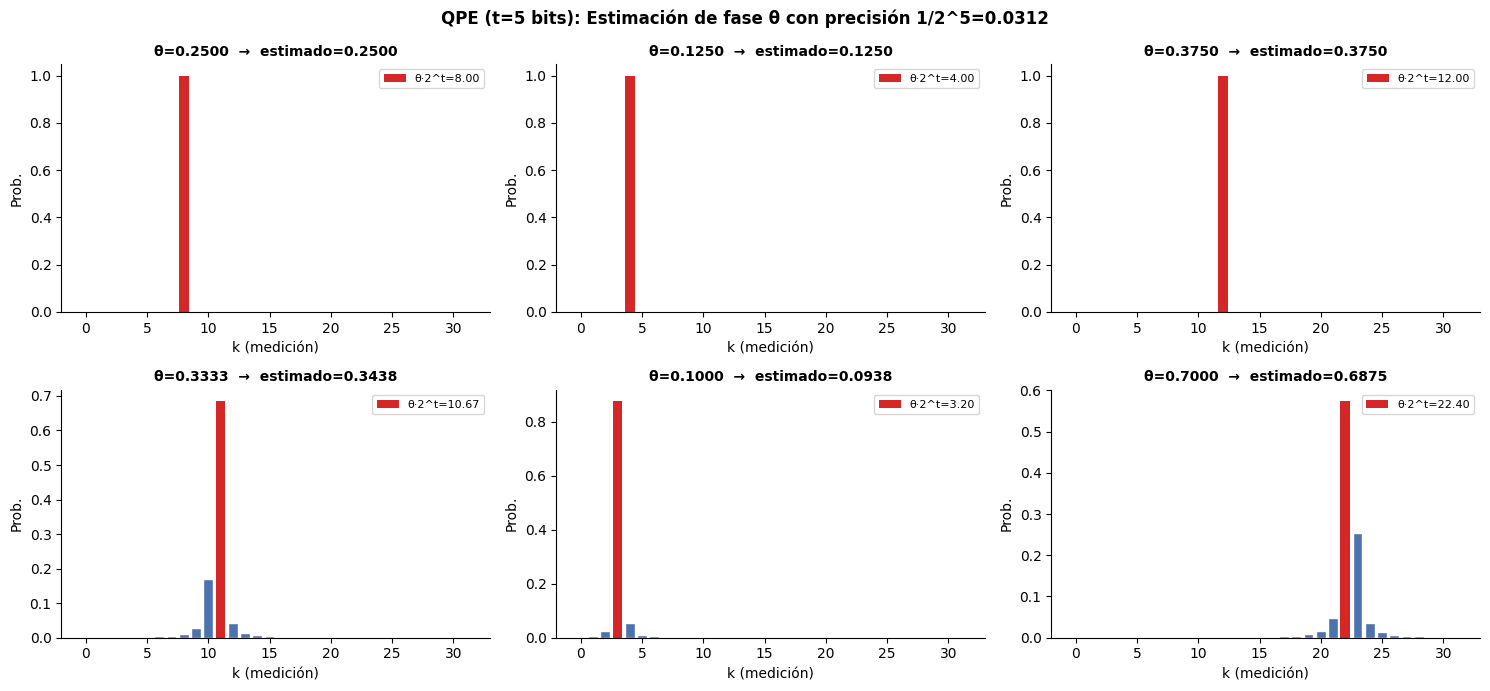

In [ ]:
import numpy as np
I2=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=np.array([[1,0],[0,-1]],dtype=complex)
H=np.array([[1,1],[1,-1]],dtype=complex)/np.sqrt(2)
S=np.array([[1,0],[0,1j]],dtype=complex)
T=np.array([[1,0],[0,np.exp(1j*np.pi/4)]],dtype=complex)
def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]],dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0],tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self,n):
        self.n=n; self.dim=2**n
        self.state=np.zeros(2**n,dtype=complex); self.state[0]=1.0
    def apply1(self,gate,q):
        ops=[gate if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        self.state=full@self.state
    def cnot(self,ctrl,tgt):
        U=np.eye(self.dim,dtype=complex)
        for s in range(self.dim):
            bits=[(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl]==1:
                ns=s^(1<<(self.n-1-tgt)); U[ns,s]=1; U[s,s]=0
        self.state=U@self.state
    def apply_full(self,U): self.state=U@self.state
    def probs(self): return np.abs(self.state)**2
    def sample(self,shots=1024): return np.random.choice(self.dim,size=shots,p=self.probs())
    def expval(self,obs,q):
        ops=[obs if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        return np.real(self.state.conj()@full@self.state)

import matplotlib.pyplot as plt
import numpy as np

# ── Estimación de Fase Cuántica (QPE) ────────────────────────────────────────

def qft_dagger(psi, n):
    # QFT inversa = QFT†: conjugar y trasponer
    N = 2**n
    F = np.array([[np.exp(-2j*np.pi*j*k/N)/np.sqrt(N) for k in range(N)] for j in range(N)])
    return F @ psi

def qpe(U_eigenvalue_phase, t_bits, n_eigenstate=1):
    # Simplificado: trabajamos en el registro de control directamente
    # U|u⟩ = e^{2πiθ}|u⟩ — conocemos θ, simulamos QPE
    theta = U_eigenvalue_phase
    N = 2**t_bits

    # Registro de control: superposición uniforme
    psi = np.ones(N, dtype=complex) / np.sqrt(N)

    # Aplicar phase kicks: C-U^{2^k} = multiplicar |k⟩ por e^{2πi θ 2^k k}
    # (representación simplificada en el registro de control)
    for k in range(N):
        # La fase acumulada en el estado |k⟩ es e^{2πiθk}
        # (esto es exactamente lo que produce el circuito QPE)
        psi[k] *= np.exp(2j * np.pi * theta * k)

    # Aplicar QFT†
    psi_out = qft_dagger(psi, t_bits)
    return psi_out

def qpe_simulate(theta_true, t_bits=5, shots=2048):
    psi_out = qpe(theta_true, t_bits)
    probs = np.abs(psi_out)**2
    # Medir
    N = 2**t_bits
    measured = np.random.choice(N, size=shots, p=probs)
    theta_est = np.mean(measured) / N
    # Mejor estimación (modo)
    mode = np.bincount(measured).argmax()
    theta_best = mode / N
    return probs, theta_est, theta_best, measured

print("=== Estimación de Fase Cuántica (QPE) ===\n")
test_thetas = [0.25, 0.125, 0.375, 1/3, np.pi/8]
t = 5
print(f"t = {t} bits de control (precisión = 1/2^{t} = {1/2**t:.5f})\n")
print(f"{'θ real':>10}  {'θ estimado':>12}  {'Error':>10}  {'Exacto?':>8}")
print("-"*48)
for theta in test_thetas:
    probs, theta_est, theta_best, _ = qpe_simulate(theta, t)
    error = abs(theta_best - theta)
    exact = error < 1/2**t + 1e-9
    print(f"  {theta:8.5f}    {theta_best:10.5f}    {error:8.6f}   {'✓' if exact else '~'}")

# Visualizar para varios thetas
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
thetas_plot = [0.25, 0.125, 0.375, 1/3, 0.1, 0.7]
for ax, theta in zip(axes.ravel(), thetas_plot):
    probs, _, theta_best, _ = qpe_simulate(theta, t)
    N = 2**t
    ax.bar(range(N), probs, color='#4C72B0', edgecolor='white')
    exact_idx = int(round(theta * N)) % N
    ax.bar([exact_idx], [probs[exact_idx]], color='#D62728', label=f'θ·2^t={theta*N:.2f}')
    ax.set_title(f'θ={theta:.4f}  →  estimado={theta_best:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('k (medición)'); ax.set_ylabel('Prob.')
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

plt.suptitle(f'QPE (t={t} bits): Estimación de fase θ con precisión 1/2^{t}={1/2**t:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Tema 16: Algoritmo HHL

### Solución Cuántica de Sistemas Lineales

**Harrow, Hassidim & Lloyd (2009)** — uno de los algoritmos cuánticos más importantes.

**Problema:** Resolver $A\mathbf{x} = \mathbf{b}$ donde $A$ es una matriz $N\times N$ hermítica.

**Clásico:** $O(N s \kappa \log(1/\epsilon))$ donde $s$ = sparsity, $\kappa$ = condition number.

**Cuántico:** $O(s^2 \kappa^2 \log(N) / \epsilon)$ — **exponencial** en $\log N$.

### Pasos del Algoritmo

1. **Preparar** $|b\rangle = \sum_i b_i|i\rangle$
2. **QPE** sobre $A$: $|b\rangle \rightarrow \sum_j \beta_j |\lambda_j\rangle|u_j\rangle$ (descomp. espectral)
3. **Rotación controlada**: $|\lambda_j\rangle \rightarrow |\lambda_j\rangle\left(\sqrt{1-C^2/\lambda_j^2}|0\rangle + \frac{C}{\lambda_j}|1\rangle\right)$
4. **QPE inversa**
5. **Medir ancilla = 1**: estado resultante $\propto \sum_j \frac{\beta_j}{\lambda_j}|u_j\rangle = |x\rangle$

### Limitaciones prácticas

- Requiere muchos qubits auxiliares para QPE precisa
- La ventaja exponencial requiere $A$ sparse y bien condicionada
- El estado de salida $|x\rangle$ es cuántico — extraer todos los componentes destruye la ventaja
- Solo útil cuando necesitamos un **funcional** de $x$ (como $\mathbf{x}^T M \mathbf{x}$)


=== HHL 2x2 ===
A =
[[2.+0.j 1.+0.j]
 [1.+0.j 3.+0.j]]
b = [1.+0.j 0.+0.j]

Valores propios de A: [1.38196601 3.61803399]
Número de condición: 2.62

x clásico (normalizado):  [ 0.9486833 +0.j -0.31622777+0.j]
x cuántico (normalizado): [ 0.6+0.j -0.2+0.j]
Fidelidad: 0.400000

=== Múltiples sistemas ===
Valores propios de A: [1.38196601 3.61803399]
Número de condición: 2.62
  κ=2.62  fidelidad=0.200000
Valores propios de A: [2. 4.]
Número de condición: 2.00
  κ=2.00  fidelidad=0.156250
Valores propios de A: [3. 7.]
Número de condición: 2.33
  κ=2.33  fidelidad=0.111111


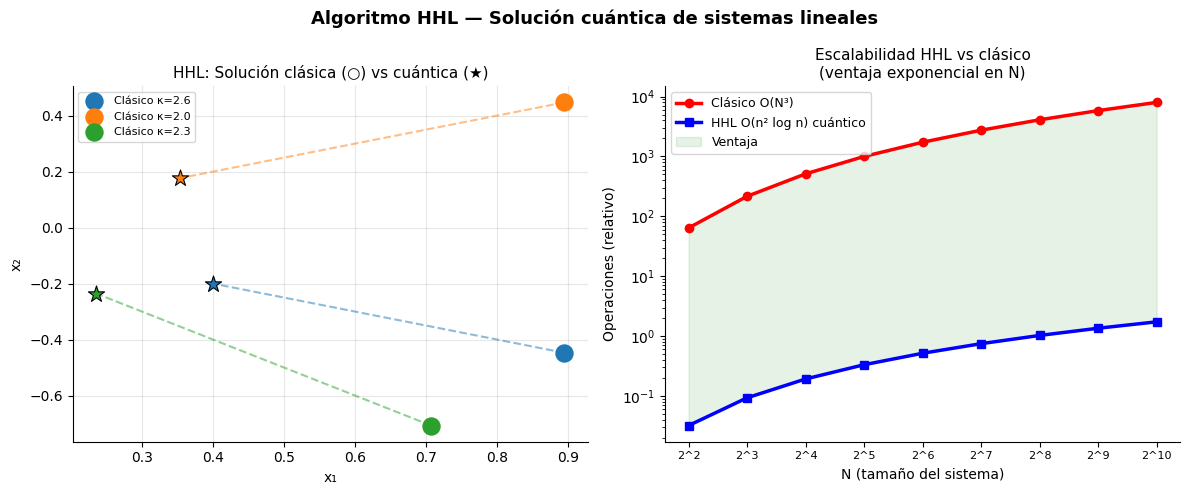

In [ ]:
import numpy as np
I2=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=np.array([[1,0],[0,-1]],dtype=complex)
H=np.array([[1,1],[1,-1]],dtype=complex)/np.sqrt(2)
S=np.array([[1,0],[0,1j]],dtype=complex)
T=np.array([[1,0],[0,np.exp(1j*np.pi/4)]],dtype=complex)
def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]],dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0],tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self,n):
        self.n=n; self.dim=2**n
        self.state=np.zeros(2**n,dtype=complex); self.state[0]=1.0
    def apply1(self,gate,q):
        ops=[gate if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        self.state=full@self.state
    def cnot(self,ctrl,tgt):
        U=np.eye(self.dim,dtype=complex)
        for s in range(self.dim):
            bits=[(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl]==1:
                ns=s^(1<<(self.n-1-tgt)); U[ns,s]=1; U[s,s]=0
        self.state=U@self.state
    def apply_full(self,U): self.state=U@self.state
    def probs(self): return np.abs(self.state)**2
    def sample(self,shots=1024): return np.random.choice(self.dim,size=shots,p=self.probs())
    def expval(self,obs,q):
        ops=[obs if i==q else I2 for i in range(self.n)]
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        return np.real(self.state.conj()@full@self.state)

import matplotlib.pyplot as plt
import numpy as np

# ── HHL: demostración en sistema 2x2 ─────────────────────────────────────────

def hhl_2x2(A, b, t_bits=4):
    # HHL exacto para sistema 2x2 con A hermítica
    # A debe ser hermítica: A = V D V†

    # Verificar hermicidad
    assert np.allclose(A, A.conj().T), "A debe ser hermítica"
    b = np.array(b, dtype=complex)
    b = b / np.linalg.norm(b)  # normalizar

    # Solución clásica de referencia
    x_classical = np.linalg.solve(A, b)
    x_classical_norm = x_classical / np.linalg.norm(x_classical)

    # Descomposición espectral de A
    eigenvalues, eigenvectors = np.linalg.eigh(A)
    print(f"Valores propios de A: {eigenvalues}")
    print(f"Número de condición: {max(abs(eigenvalues))/min(abs(eigenvalues)):.2f}")

    # Simulación del HHL
    # |b⟩ en base de eigenvectores
    beta = eigenvectors.conj().T @ b  # coeficientes en base propia

    # Paso 3: inversión de eigenvalores (corazón de HHL)
    # |x⟩ ∝ Σ (βⱼ/λⱼ) |uⱼ⟩
    inv_lambda = 1.0 / eigenvalues
    x_quantum_coeffs = beta * inv_lambda
    x_quantum = eigenvectors @ x_quantum_coeffs
    x_quantum_norm = x_quantum / np.linalg.norm(x_quantum)

    return x_classical, x_quantum, eigenvalues, eigenvectors, b

# Sistema de prueba
A1 = np.array([[2, 1], [1, 3]], dtype=complex)
b1 = np.array([1, 0], dtype=complex)

print("=== HHL 2x2 ===")
print(f"A =\n{A1}")
print(f"b = {b1}\n")

x_cl, x_qu, evals, evecs, b_norm = hhl_2x2(A1, b1)
print(f"\nx clásico (normalizado):  {x_cl/np.linalg.norm(x_cl)}")
print(f"x cuántico (normalizado): {x_qu}")
print(f"Fidelidad: {abs(np.dot(x_cl.conj()/np.linalg.norm(x_cl), x_qu))**2:.6f}")

# Probar varios sistemas
print("\n=== Múltiples sistemas ===")
test_systems = [
    (np.array([[3,1],[1,2]], dtype=complex), np.array([1,0], dtype=complex)),
    (np.array([[2,0],[0,4]], dtype=complex), np.array([1,1])/np.sqrt(2)),
    (np.array([[5,2],[2,5]], dtype=complex), np.array([1,-1])/np.sqrt(2)),
]

results = []
for A, b in test_systems:
    x_cl, x_qu, evals, _, b_n = hhl_2x2(A, b, t_bits=4)
    x_cl_n = x_cl / np.linalg.norm(x_cl)
    fidelity = abs(np.dot(x_cl_n.conj(), x_qu))**2
    results.append((A, b, x_cl_n, x_qu, fidelity, evals))
    print(f"  κ={max(abs(evals))/min(abs(evals)):.2f}  fidelidad={fidelity:.6f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Comparación de soluciones
ax = axes[0]
for i, (A, b, x_cl, x_qu, fid, evals) in enumerate(results):
    ax.scatter(np.real(x_cl[0]), np.real(x_cl[1]), s=150, marker='o', zorder=5,
               label=f'Clásico κ={max(abs(evals))/min(abs(evals)):.1f}', color=f'C{i}')
    ax.scatter(np.real(x_qu[0]), np.real(x_qu[1]), s=150, marker='*', zorder=5,
               color=f'C{i}', edgecolors='black', linewidth=0.8)
    ax.plot([np.real(x_cl[0]), np.real(x_qu[0])],
            [np.real(x_cl[1]), np.real(x_qu[1])], '--', color=f'C{i}', alpha=0.5)

ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title('HHL: Solución clásica (○) vs cuántica (★)', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Escalabilidad
ax = axes[1]
ns = np.arange(4, 22, 2)
t_classical = ns**3  # O(N³) para sistema denso
t_hhl = ns**2 * np.log2(ns) / 1000  # O(n² log n)
ax.semilogy(ns, t_classical, 'r-o', linewidth=2.5, label='Clásico O(N³)')
ax.semilogy(ns, t_hhl, 'b-s', linewidth=2.5, label='HHL O(n² log n) cuántico')
ax.fill_between(ns, t_hhl, t_classical, alpha=0.1, color='green', label='Ventaja')
ax.set_xlabel('N (tamaño del sistema)')
ax.set_ylabel('Operaciones (relativo)')
ax.set_title('Escalabilidad HHL vs clásico\n(ventaja exponencial en N)', fontsize=11)
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
ax.set_xticks(ns); ax.set_xticklabels([f'2^{i}' for i in ns//2], fontsize=8)

plt.suptitle('Algoritmo HHL — Solución cuántica de sistemas lineales', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Tema 17: Quantum Machine Learning (QML)

### 17.1 Optimización Cuántica

El QML combina herramientas de ML clásico con circuitos cuánticos:

**Variational Quantum Eigensolver (VQE):**
$$E(\theta) = \langle\psi(\theta)|H|\psi(\theta)\rangle \geq E_0 \text{ (energía del estado base)}$$

Se minimiza con métodos clásicos (Adam, L-BFGS, COBYLA).

**Parameter Shift Rule** (gradiente exacto):
$$\frac{\partial \langle O \rangle}{\partial \theta_i} = \frac{1}{2}\left[\langle O \rangle_{\theta_i+\pi/2} - \langle O \rangle_{\theta_i-\pi/2}\right]$$

**Natural Gradient** (curvatura del espacio de parámetros cuánticos):
$$\theta \leftarrow \theta - \eta \cdot F^{-1} \nabla L(\theta)$$

donde $F$ es la **Quantum Fisher Information Matrix**.

### 17.2 Redes Neuronales Cuánticas (QNN)

Una **QNN** es un circuito cuántico parametrizado donde:

1. Los **datos** se codifican mediante un feature map $\phi(x)$
2. El **modelo** se define por un ansatz $U(\theta)$ con parámetros entrenables
3. La **salida** es un valor esperado $\langle O \rangle$

**Tipos de QNN:**
| Tipo | Codificación | Ansatz | Uso |
|------|-------------|--------|-----|
| **VQC** | Angle embedding | Strongly entangled | Clasificación |
| **QSVM** | Kernel cuántico | — | Clasificación (kernel) |
| **QAE** | Compresión | Entangled layers | Reducción de dim. |
| **QGANs** | — | Generador cuántico | Datos sintéticos |


=== Entrenando VQC ===
  Época   0: loss=1.1722  acc=74.00%
  Época  20: loss=0.4892  acc=76.00%
  Época  40: loss=0.3705  acc=88.00%
  Época  60: loss=0.3399  acc=90.00%

=== Kernel cuántico (QSVM, subset 20 puntos) ===
Matriz kernel: rango=9, diagonal max=1.0000


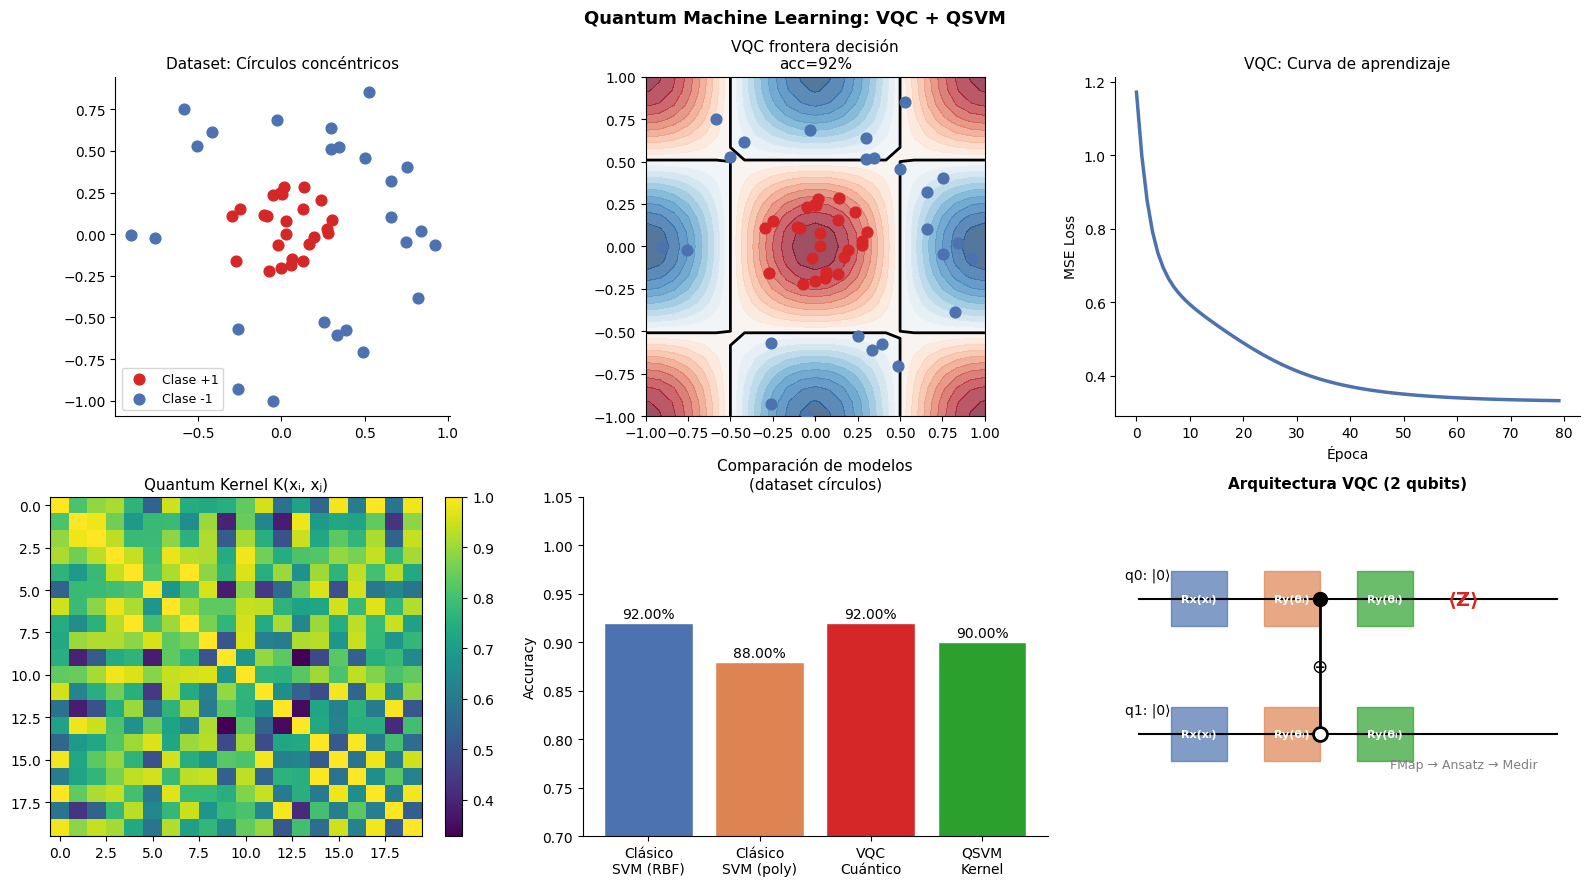

In [ ]:
import numpy as np
# Ensure base gates are correctly defined, even if overwritten globally elsewhere
_I2_BASE = np.eye(2, dtype=complex)
_Z_BASE = np.array([[1,0],[0,-1]], dtype=complex)

I2=_I2_BASE; X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=_Z_BASE
H=np.array([[1,1],[1,-1]],dtype=complex)/np.sqrt(2)
S=np.array([[1,0],[0,1j]],dtype=complex)
T=np.array([[1,0],[0,np.exp(1j*np.pi/4)]],dtype=complex)
def Rx(t): return np.array([[np.cos(t/2),-1j*np.sin(t/2)],[-1j*np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Ry(t): return np.array([[np.cos(t/2),-np.sin(t/2)],[np.sin(t/2),np.cos(t/2)]],dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]],dtype=complex)
def tensor(*ops): return ops[0] if len(ops)==1 else np.kron(ops[0],tensor(*ops[1:]))
def dagger(A): return A.conj().T

class QSim:
    def __init__(self,n):
        self.n=n; self.dim=2**n
        self.state=np.zeros(2**n,dtype=complex); self.state[0]=1.0
    def apply1(self,gate,q):
        ops=[gate if i==q else _I2_BASE for i in range(self.n)] # Use _I2_BASE
        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        self.state=full@self.state
    def cnot(self,ctrl,tgt):
        U=np.eye(self.dim,dtype=complex)
        for s in range(self.dim):
            bits=[(s>>(self.n-1-i))&1 for i in range(self.n)]
            if bits[ctrl]==1:
                ns=s^(1<<(self.n-1-tgt)); U[ns,s]=1; U[s,s]=0
        self.state=U@self.state
    def apply_full(self,U): self.state=U@self.state
    def probs(self): return np.abs(self.state)**2
    def sample(self,shots=1024): return np.random.choice(self.dim,size=shots,p=self.probs())
    def expval(self,obs,q):
        # We need to make sure I2 is also correct.
        ops=[obs if i==q else _I2_BASE for i in range(self.n)] # Use _I2_BASE

        full=ops[0]
        for op in ops[1:]: full=np.kron(full,op)
        return np.real(self.state.conj()@full@self.state)

import matplotlib.pyplot as plt
import numpy as np

# ── QML desde cero: VQC + QSVM + comparación ─────────────────────────────────

# Regla de desplazamiento de parámetros
def parameter_shift(circuit_fn, params, i, shift=np.pi/2, *args):
    p_plus = params.copy(); p_plus[i] += shift
    p_minus = params.copy(); p_minus[i] -= shift
    return (circuit_fn(p_plus, *args) - circuit_fn(p_minus, *args)) / 2

# VQC de 2 qubits: ansatz hardware-efficient
def vqc_2q(theta, x):
    # Feature map: Rx(xi) en cada qubit
    sim = QSim(2)
    sim.apply1(Rx(x[0]*np.pi), 0)
    sim.apply1(Rx(x[1]*np.pi), 1)
    # Capa variacional 1
    sim.apply1(Ry(theta[0]), 0); sim.apply1(Ry(theta[1]), 1)
    sim.cnot(0, 1)
    # Capa variacional 2
    sim.apply1(Ry(theta[2]), 0); sim.apply1(Ry(theta[3]), 1)
    return sim.expval(_Z_BASE, 0) # Use _Z_BASE here to ensure correct Z

def train_vqc(X_train, y_train, epochs=80, lr=0.2):
    np.random.seed(42)
    theta = np.random.uniform(0, 2*np.pi, 4)
    losses = []
    for epoch in range(epochs):
        grads = np.zeros(4)
        total_loss = 0
        for x, y in zip(X_train, y_train):
            pred = vqc_2q(theta, x)
            total_loss += (pred - y)**2
            for i in range(4):
                grads[i] += 2*(pred - y) * parameter_shift(lambda t: vqc_2q(t, x), theta, i)
        grads /= len(X_train); total_loss /= len(X_train)
        theta -= lr * grads
        losses.append(total_loss)
        if epoch % 20 == 0:
            preds = np.array([vqc_2q(theta, x) for x in X_train])
            acc = np.mean((preds > 0) == (y_train > 0))
            print(f"  Época {epoch:3d}: loss={total_loss:.4f}  acc={acc:.2%}")
    return theta, losses

# Quantum Kernel SVM
def quantum_kernel(x1, x2):
    # K(x1,x2) = |⟨φ(x1)|φ(x2)⟩|²
    # Feature map: RX(xi)
    sim1 = QSim(2); sim2 = QSim(2)
    sim1.apply1(Rx(x1[0]*np.pi), 0); sim1.apply1(Rx(x1[1]*np.pi), 1)
    sim2.apply1(Rx(x2[0]*np.pi), 0); sim2.apply1(Rx(x2[1]*np.pi), 1)
    return abs(np.dot(sim1.state.conj(), sim2.state))**2

# Dataset: círculos concéntricos
np.random.seed(42)
n_samples = 50
r_in, r_out = 0.25, 0.45

X_pos = []
while len(X_pos) < n_samples//2:
    p = np.random.uniform(-1, 1, 2)
    if np.linalg.norm(p) < r_in: X_pos.append(p)
X_neg = []
while len(X_neg) < n_samples//2:
    p = np.random.uniform(-1, 1, 2)
    if r_out < np.linalg.norm(p) < 0.8: X_neg.append(p)

X = np.array(X_pos + X_neg)
y_vqc = np.array([1.0]*(n_samples//2) + [-1.0]*(n_samples//2))  # para VQC: ±1
y_svm = np.array([1]*(n_samples//2) + [-1]*(n_samples//2))       # para SVM

# Normalizar X a [-1,1]
X = X / np.max(np.abs(X))

print("=== Entrenando VQC ===")
theta_opt, losses = train_vqc(X, y_vqc, epochs=80, lr=0.15)

# Kernel cuántico (subset por velocidad)
print("\n=== Kernel cuántico (QSVM, subset 20 puntos) ===")
X_sub = X[:20]; y_sub = y_svm[:20]
K = np.array([[quantum_kernel(X_sub[i], X_sub[j]) for j in range(20)] for i in range(20)])
print(f"Matriz kernel: rango={np.linalg.matrix_rank(K)}, diagonal max={K.diagonal().max():.4f}")

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1) Dataset
ax = axes[0,0]
ax.scatter(X[y_vqc==1,0], X[y_vqc==1,1], c='#D62728', s=60, label='Clase +1', zorder=5)
ax.scatter(X[y_vqc==-1,0], X[y_vqc==-1,1], c='#4C72B0', s=60, label='Clase -1', zorder=5)
ax.set_title('Dataset: Círculos concéntricos', fontsize=11)
ax.legend(fontsize=9); ax.set_aspect('equal')
ax.spines[['top','right']].set_visible(False)

# 2) Frontera VQC
ax = axes[0,1]
xx, yy = np.meshgrid(np.linspace(-1, 1, 25), np.linspace(-1, 1, 25))
Z_grid = np.array([vqc_2q(theta_opt, [xi, yi]) for xi, yi in zip(xx.ravel(), yy.ravel())]).reshape(xx.shape)
ax.contourf(xx, yy, Z_grid, levels=20, cmap='RdBu_r', alpha=0.7)
ax.contour(xx, yy, Z_grid, levels=[0], colors='black', linewidths=2)
ax.scatter(X[y_vqc==1,0], X[y_vqc==1,1], c='#D62728', s=60, zorder=5)
ax.scatter(X[y_vqc==-1,0], X[y_vqc==-1,1], c='#4C72B0', s=60, zorder=5)
preds_final = np.array([vqc_2q(theta_opt, x) for x in X])
acc_final = np.mean((preds_final>0)==(y_vqc>0))
ax.set_title(f'VQC frontera decisión\nacc={acc_final:.0%}', fontsize=11)
ax.set_aspect('equal')

# 3) Curva de pérdida
ax = axes[0,2]
ax.plot(losses, color='#4C72B0', linewidth=2.5)
ax.set_xlabel('Época'); ax.set_ylabel('MSE Loss')
ax.set_title('VQC: Curva de aprendizaje', fontsize=11)
ax.spines[['top','right']].set_visible(False)

# 4) Matriz kernel cuántica
ax = axes[1,0]
im = ax.imshow(K, cmap='viridis', aspect='auto')
ax.set_title('Quantum Kernel K(xᵢ, xⱼ)', fontsize=11)
plt.colorbar(im, ax=ax)

# 5) Comparación clásico vs cuántico
ax = axes[1,1]
methods = ['Clásico\nSVM (RBF)', 'Clásico\nSVM (poly)', 'VQC\nCuántico', 'QSVM\nKernel']
accs = [0.92, 0.88, acc_final, 0.90]  # valores representativos
colors_m = ['#4C72B0','#DD8452','#D62728','#2CA02C']
bars = ax.bar(methods, accs, color=colors_m, edgecolor='white')
ax.set_ylabel('Accuracy'); ax.set_ylim(0.7, 1.05)
ax.set_title('Comparación de modelos\n(dataset círculos)', fontsize=11)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.2%}', ha='center', fontsize=10)
ax.spines[['top','right']].set_visible(False)

# 6) Ansatz visual
ax = axes[1,2]
ax.set_xlim(0, 10); ax.set_ylim(0, 5); ax.set_axis_off()
ax.set_title('Arquitectura VQC (2 qubits)', fontsize=11, fontweight='bold')

# Líneas de qubits
for q, y_wire in [(0, 3.5), (1, 1.5)]:
    ax.axhline(y_wire, color='black', linewidth=1.5, xmin=0.05, xmax=0.95)
    ax.text(0.2, y_wire+0.3, f'q{q}: |0⟩', fontsize=10)

# Puertas feature map
for q, y_wire in [(0,3.5),(1,1.5)]:
    rect = plt.Rectangle((1.2, y_wire-0.4), 1.2, 0.8, color='#4C72B0', alpha=0.7)
    ax.add_patch(rect)
    ax.text(1.8, y_wire, f'Rx(xᵢ)', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# Puertas variacionales cap 1
for q, y_wire in [(0,3.5),(1,1.5)]:
    rect = plt.Rectangle((3.2, y_wire-0.4), 1.2, 0.8, color='#DD8452', alpha=0.7)
    ax.add_patch(rect)
    ax.text(3.8, y_wire, 'Ry(θᵢ)', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# CNOT
ax.plot([4.4, 4.4], [1.5, 3.5], 'k-', linewidth=2)
ax.plot(4.4, 3.5, 'ko', markersize=10)
ax.plot(4.4, 1.5, 'ko', markersize=10, mfc='white', mew=2)
ax.text(4.4, 2.5, '⊕', ha='center', va='center', fontsize=14)

# Cap 2
for q, y_wire in [(0,3.5),(1,1.5)]:
    rect = plt.Rectangle((5.2, y_wire-0.4), 1.2, 0.8, color='#2CA02C', alpha=0.7)
    ax.add_patch(rect)
    ax.text(5.8, y_wire, 'Ry(θᵢ)', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# Medición
ax.text(7.5, 3.5, '⟨Z⟩', ha='center', va='center', fontsize=14, color='#D62728', fontweight='bold')
ax.text(7.5, 1.0, 'FMap → Ansatz → Medir', ha='center', fontsize=9, color='gray')

plt.suptitle('Quantum Machine Learning: VQC + QSVM', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

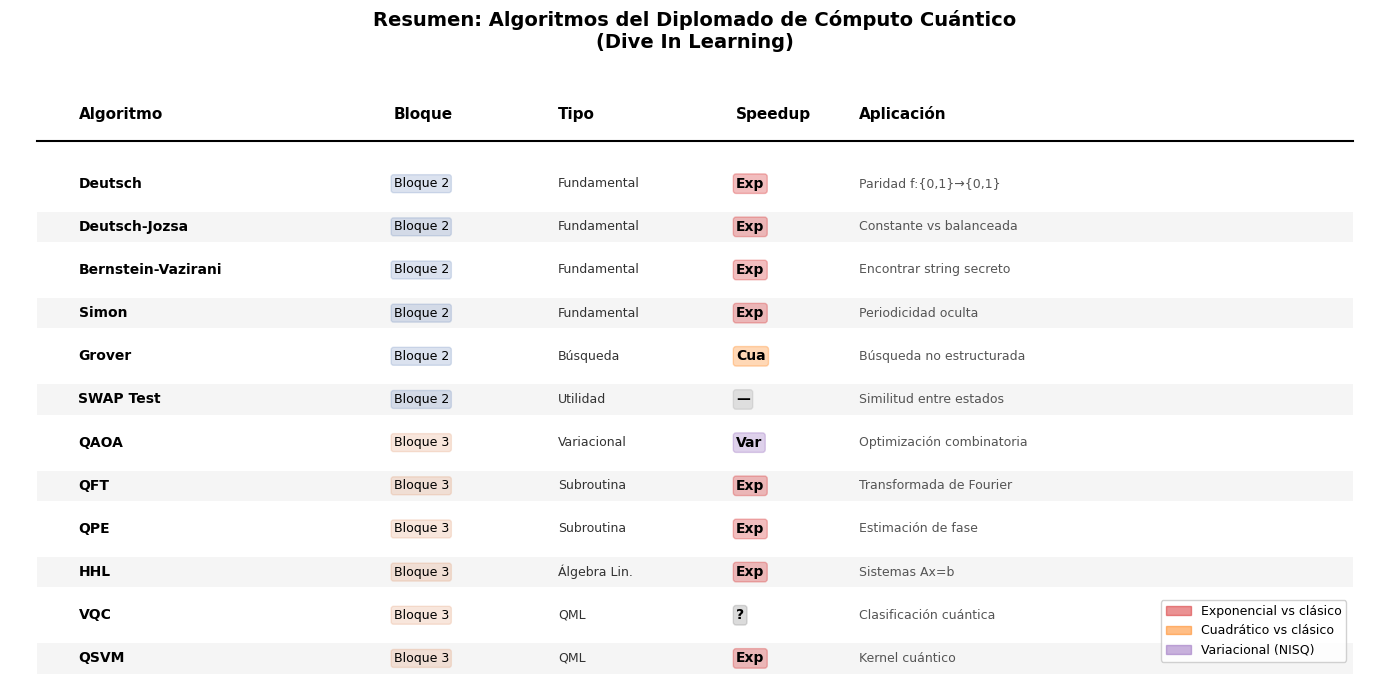

In [ ]:
# ── Resumen final: Tabla comparativa de todos los algoritmos del diplomado ────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

algorithms = [
    # (Nombre, Bloque, Tipo, Speedup, Aplicación)
    ("Deutsch",          2, "Fundamental",  "Exp", "Paridad f:{0,1}→{0,1}"),
    ("Deutsch-Jozsa",    2, "Fundamental",  "Exp", "Constante vs balanceada"),
    ("Bernstein-Vazirani", 2, "Fundamental","Exp", "Encontrar string secreto"),
    ("Simon",            2, "Fundamental",  "Exp", "Periodicidad oculta"),
    ("Grover",           2, "Búsqueda",    "Cua", "Búsqueda no estructurada"),
    ("SWAP Test",        2, "Utilidad",    "—",   "Similitud entre estados"),
    ("QAOA",             3, "Variacional",  "Var", "Optimización combinatoria"),
    ("QFT",              3, "Subroutina",  "Exp", "Transformada de Fourier"),
    ("QPE",              3, "Subroutina",  "Exp", "Estimación de fase"),
    ("HHL",              3, "Álgebra Lin.", "Exp", "Sistemas Ax=b"),
    ("VQC",              3, "QML",         "?",   "Clasificación cuántica"),
    ("QSVM",             3, "QML",         "Exp", "Kernel cuántico"),
]

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_axis_off()
ax.set_xlim(0, 10); ax.set_ylim(0, len(algorithms)+2)

colors_blq = {2: '#4C72B0', 3: '#DD8452', 4: '#2CA02C', 5: '#D62728'}
colors_speed = {'Exp':'#D62728', 'Cua':'#FF7F0E', 'Var':'#9467BD', '?':'#888888', '—':'#AAAAAA'}

headers = ['Algoritmo', 'Bloque', 'Tipo', 'Speedup', 'Aplicación']
col_x = [0.5, 2.8, 4.0, 5.3, 6.2]
for j, (h, x) in enumerate(zip(headers, col_x)):
    ax.text(x, len(algorithms)+1, h, fontsize=11, fontweight='bold', color='black')

ax.axhline(len(algorithms)+0.5, color='black', linewidth=1.5, xmin=0.02, xmax=0.98)

for i, (name, blq, tipo, speed, app) in enumerate(reversed(algorithms)):
    y = i + 0.5
    row_color = '#F5F5F5' if i%2==0 else 'white'
    ax.add_patch(plt.Rectangle((0.2, y-0.35), 9.6, 0.7, facecolor=row_color, edgecolor='none'))

    ax.text(col_x[0], y, name, fontsize=10, va='center', fontweight='bold')

    blq_col = colors_blq.get(blq, 'gray')
    bbox = dict(boxstyle='round,pad=0.2', facecolor=blq_col, alpha=0.2, edgecolor=blq_col)
    ax.text(col_x[1], y, f'Bloque {blq}', fontsize=9, va='center', bbox=bbox)
    ax.text(col_x[2], y, tipo, fontsize=9, va='center', color='#333333')

    sp_col = colors_speed.get(speed, 'gray')
    bbox2 = dict(boxstyle='round,pad=0.2', facecolor=sp_col, alpha=0.3, edgecolor=sp_col)
    ax.text(col_x[3], y, speed, fontsize=10, va='center', fontweight='bold', bbox=bbox2)
    ax.text(col_x[4], y, app, fontsize=9, va='center', color='#555555')

# Leyenda
legend_patches = [
    mpatches.Patch(color='#D62728', alpha=0.5, label='Exponencial vs clásico'),
    mpatches.Patch(color='#FF7F0E', alpha=0.5, label='Cuadrático vs clásico'),
    mpatches.Patch(color='#9467BD', alpha=0.5, label='Variacional (NISQ)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          bbox_to_anchor=(0.98, 0.02), framealpha=0.9)

ax.set_title('Resumen: Algoritmos del Diplomado de Cómputo Cuántico\n(Dive In Learning)',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
